In [1]:
import warnings, os, copy, random, gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model    import Ridge, RidgeCV   # ← tek satır yeterli
from sklearn.preprocessing   import RobustScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics         import mean_squared_error, mean_absolute_error
from lightgbm                import LGBMRegressor, early_stopping as lgb_es, log_evaluation as lgb_lev
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost                 import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data    import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint

In [2]:
DATA_PATH = "C:/Users/kerem/Desktop/EnerjiSon/claude/birlesik_veri.csv"     # ← gerekirse güncelleyin

TRAIN_YEARS       = [2021, 2022, 2023]
FIYAT_TRAIN_YEARS = [2022, 2023]     # 2021 fiyat rejimi ~5× düşük
VAL_YEAR          = 2024
TEST_YEAR         = 2025

SARIMAX_HORIZON = 7    # rolling forecast adımı (gün)

LOOKBACK    = 30       # CNN-LSTM & TFT encoder penceresi (gün)
DL_HORIZON  = 7        # CNN-LSTM & TFT tahmin ufku (gün)
BATCH_SIZE  = 64
MAX_EPOCHS  = 60
PATIENCE    = 12
LR          = 1e-3

OPTUNA_TRIALS = 20     # 0 → Optuna atlanır

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cihaz: {DEVICE}  |  PyTorch: {torch.__version__}")

Cihaz: cpu  |  PyTorch: 2.11.0+cpu


In [3]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, window=48):
        self.X = X
        self.y = y
        self.window = window

    def __len__(self):
        return len(self.X) - self.window

    def __getitem__(self, idx):
        x = self.X[idx:idx+self.window]
        y = self.y[idx+self.window]

        return (
            torch.tensor(x, dtype=torch.float32).clone().detach(),
            torch.tensor(y, dtype=torch.float32).clone().detach()
        )

VERİ YÜKLEME & GÜNLÜK RESAMPLE

In [4]:
def load_daily(path: str) -> pd.DataFrame:
    """
    Saatlik CSV → günlük DataFrame.
      tuketim_mwh / uretim_mwh : sum  (günlük toplam enerji)
      fiyat_tl                 : mean (günlük ortalama piyasa fiyatı)
      hava değişkenleri        : mean / sum
      is_weekend / is_holiday  : max  (gün içinde herhangi 1 saat = 1)
    Tüm günler reindex ile garantilenir; fiyat NaN → interpolasyon.
    """
    df = pd.read_csv(path)
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values("Datetime").set_index("Datetime")

    daily = df.resample("D").agg({
        "uretim_mwh"          : "sum",
        "tuketim_mwh"         : "sum",
        "fiyat_tl"            : "mean",
        "sicaklik"            : "mean",
        "hissedilen_sicaklik" : "mean",
        "nem"                 : "mean",
        "bulut_ortus"         : "mean",
        "ruzgar_hizi"         : "mean",
        "yagis"               : "sum",
        "is_weekend"          : "max",
        "is_holiday"          : "max",
    })

    # Tam tarih dizisi garantisi — eksik günler ffill ile doldurulur
    full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
    daily = daily.reindex(full_idx).ffill()

    # fiyat_tl'deki 17 NaN → zaman interpolasyonu
    daily["fiyat_tl"] = daily["fiyat_tl"].interpolate(method="time")

    print(f"Günlük veri: {daily.shape}  "
          f"[{daily.index.min().date()} → {daily.index.max().date()}]")
    return daily

ÖZELLİK MÜHENDİSLİĞİ

In [5]:
# TFT: gelecekte bilinebilecek özellikler (hesaplanabilir takvim & Fourier)
KNOWN_FUTURE_REALS = [
    "sin_7", "cos_7", "sin_365", "cos_365", "sin_365_2", "cos_365_2",
    # "gun_sin", "gun_cos",  ← KALDIRILDI
    "ay_sin", "ay_cos",
]
KNOWN_FUTURE_CATS = ["is_weekend", "is_holiday"]


def add_features(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """
    add_features() güncellenmiş versiyonu.
    Değişiklik: gun_sin/gun_cos kaldırıldı (sin_7/cos_7 ile kolineer).
    ay_sin/ay_cos korunuyor (12 aylık periyot, sin_365 ile tam örtüşmüyor).
    """
    df = df.copy()
    t  = np.arange(len(df))

    # Haftalık Fourier (T=7) — korunuyor
    df["sin_7"]     = np.sin(2 * np.pi * t / 7)
    df["cos_7"]     = np.cos(2 * np.pi * t / 7)

    # Yıllık Fourier (T=365.25) — korunuyor
    df["sin_365"]   = np.sin(2 * np.pi * t / 365.25)
    df["cos_365"]   = np.cos(2 * np.pi * t / 365.25)
    df["sin_365_2"] = np.sin(4 * np.pi * t / 365.25)
    df["cos_365_2"] = np.cos(4 * np.pi * t / 365.25)

    # DÜZELTME: gun_sin / gun_cos KALDIRILDI (sin_7/cos_7 ile lineer bağımlı)
    # df["gun_sin"] = ...  ← SİLİNDİ
    # df["gun_cos"] = ...  ← SİLİNDİ

    # Aylık döngüsel — korunuyor (12-periyot, Fourier'den farklı)
    df["ay_sin"]  = np.sin(2 * np.pi * df.index.month / 12)
    df["ay_cos"]  = np.cos(2 * np.pi * df.index.month / 12)

    # Hava türevleri (değişiklik yok)
    df["sicaklik_sq"] = df["sicaklik"] ** 2
    df["hdd_proxy"]   = (18 - df["sicaklik"]).clip(lower=0)
    df["cdd_proxy"]   = (df["sicaklik"] - 22).clip(lower=0)
    df["heat_index"]  = df["sicaklik"] * df["nem"] / 100
    df["dew_point"]   = df["sicaklik"] - df["nem"] / 5

    for col in ["sicaklik", "hissedilen_sicaklik", "nem",
                "ruzgar_hizi", "bulut_ortus", "yagis",
                "sicaklik_sq", "hdd_proxy", "cdd_proxy",
                "heat_index", "dew_point"]:
        df[f"{col}_lag1"] = df[col].shift(1)

    for lag in [7, 14, 30]:
        df[f"{target}_lag{lag}"] = df[target].shift(lag)

    df[f"{target}_roll7_mean"]  = df[target].shift(1).rolling(7).mean()
    df[f"{target}_roll7_std"]   = df[target].shift(1).rolling(7).std()
    df[f"{target}_roll30_mean"] = df[target].shift(1).rolling(30).mean()
    df[f"{target}_roll30_std"]  = df[target].shift(1).rolling(30).std()

    if target == "fiyat_tl":
        df["net_load_lag7"]   = (df["tuketim_mwh"] - df["uretim_mwh"]).shift(7)
        df["lag_tuketim_7"]   = df["tuketim_mwh"].shift(7)
        df["lag_uretim_7"]    = df["uretim_mwh"].shift(7)
        df["price_diff_7"]    = df["fiyat_tl"].diff(7).shift(1)
        df["roll_price_max7"] = df["fiyat_tl"].rolling(7).max().shift(1)
        df["roll_price_min7"] = df["fiyat_tl"].rolling(7).min().shift(1)

    if "is_price_spike" in df.columns:
        df["spike_lag7"]  = df["is_price_spike"].shift(7)
        df["spike_lag14"] = df["is_price_spike"].shift(14)
        df["dip_lag7"]    = df["is_price_dip"].shift(7)

    df = df.dropna().copy()
    df["time_idx"] = np.arange(len(df), dtype=int)
    df["group"]    = "TR"
    return df



def get_feature_cols(target: str, df: pd.DataFrame) -> list:
    """
    Model girdi sütunları: ham t-anı değişkenler ve leakage kaynakları dışlanır.
    is_weekend / is_holiday TFT için KNOWN_FUTURE_CATS'te, diğerleri için feat'te.
    """
    drop = {
        "tuketim_mwh", "uretim_mwh", "fiyat_tl",
        # t-anı ham hava — lag1 versiyonları feat_cols içinde
        "sicaklik", "hissedilen_sicaklik", "nem",
        "bulut_ortus", "ruzgar_hizi", "yagis",
        "sicaklik_sq", "hdd_proxy", "cdd_proxy", "heat_index", "dew_point",
        # TFT yardımcı sütunlar
        "time_idx", "group",
    }
    return [c for c in df.columns if c not in drop and c != target]


print("\nVeri yükleniyor...")
raw_daily = load_daily(DATA_PATH)

print("Özellikler hesaplanıyor...")
df_t = add_features(raw_daily, "tuketim_mwh")
df_f = add_features(raw_daily, "fiyat_tl")
df_f = df_f[df_f.index.year >= 2022].copy()
# time_idx'i fiyat için de sıfırdan başlat
df_f["time_idx"] = np.arange(len(df_f), dtype=int)

EXCLUDE = ["tuketim_mwh", "fiyat_tl", "uretim_mwh",
           "is_price_spike", "is_price_dip"]   # ← ham kolonlar dışarı

feat_t = [c for c in get_feature_cols("tuketim_mwh", df_t) if c not in EXCLUDE]
feat_f = [c for c in get_feature_cols("fiyat_tl", df_f) if c not in EXCLUDE]

print(f"Tüketim: {df_t.shape}  |  Özellik sayısı: {len(feat_t)}")
print(f"Fiyat  : {df_f.shape}  |  Özellik sayısı: {len(feat_f)}")


Veri yükleniyor...
Günlük veri: (1826, 11)  [2021-01-01 → 2025-12-31]
Özellikler hesaplanıyor...
Tüketim: (1796, 44)  |  Özellik sayısı: 28
Fiyat  : (1461, 50)  |  Özellik sayısı: 34


TRAIN / VAL / TEST BÖLME

In [6]:
def year_split(df, train_yrs, val_yr, test_yr):
    return (df[df.index.year.isin(train_yrs)].copy(),
            df[df.index.year == val_yr].copy(),
            df[df.index.year == test_yr].copy())


train_t, val_t, test_t = year_split(df_t, TRAIN_YEARS,       VAL_YEAR, TEST_YEAR)
train_f, val_f, test_f = year_split(df_f, FIYAT_TRAIN_YEARS, VAL_YEAR, TEST_YEAR)

# Kanonik y — tüm modeller bu diziye göre ölçülür
y_val_t  = val_t["tuketim_mwh"].values
y_test_t = test_t["tuketim_mwh"].values
y_val_f  = val_f["fiyat_tl"].values
y_test_f = test_f["fiyat_tl"].values

print(f"\nTüketim → Train:{len(train_t)}  Val:{len(val_t)}  Test:{len(test_t)}")
print(f"Fiyat   → Train:{len(train_f)}  Val:{len(val_f)}  Test:{len(test_f)}")


Tüketim → Train:1065  Val:366  Test:365
Fiyat   → Train:730  Val:366  Test:365


METRİK

In [7]:
def evaluate(y_true, y_pred, label="") -> dict:
    """RMSE / MAE / sMAPE / NRMSE — tail-align ile farklı uzunluklar hizalanır."""
    yt = np.asarray(y_true).ravel()
    yp = np.asarray(y_pred).ravel()
    n  = min(len(yt), len(yp))
    yt, yp = yt[-n:], yp[-n:]
    mask = ~(np.isnan(yt) | np.isnan(yp))
    yt, yp = yt[mask], yp[mask]

    rmse  = np.sqrt(mean_squared_error(yt, yp))
    mae   = mean_absolute_error(yt, yp)
    smape = 100 * np.mean(2 * np.abs(yp - yt) / (np.abs(yt) + np.abs(yp) + 1e-8))
    nrmse = rmse / (yt.max() - yt.min() + 1e-8)

    if label:
        print(f"  {label:<34} RMSE={rmse:>12.1f}  MAE={mae:>11.1f}"
              f"  sMAPE={smape:>6.2f}%  NRMSE={nrmse:.4f}")
    return dict(RMSE=rmse, MAE=mae, sMAPE=smape, NRMSE=nrmse)

SARIMAX BAZ MODELİ

In [8]:
# SARIMAX(1,1,1)(1,0,1,7) — günlük, haftalık mevsimsellik
# exog: hava lag1 (tahmin anında bilinebilir) + Fourier + takvim
#
# Rolling forecast — .apply() tabanlı:
#   Val tahmin  : seen = train
#   Test tahmin : seen = train + val  (gerçek değerler dahil)
#   Her adımda parametreler sabit, yalnızca state güncellenir
# ─────────────────────────────────────────────────────────────────────────────

SARIMAX_EXOG = [
    "sicaklik_lag1", "hissedilen_sicaklik_lag1",
    "nem_lag1", "ruzgar_hizi_lag1", "yagis_lag1",
    "is_weekend", "is_holiday",
    "sin_7", "cos_7", "sin_365", "cos_365",
]

print("\n" + "="*65)
print("BÖLÜM 5 — SARIMAX")
print("="*65)


def _to_series(df, col):
    s = df[col].copy()
    s.index = pd.DatetimeIndex(s.index).normalize()
    return s.asfreq("D").interpolate(method="time")


def _to_exog(df, cols):
    X = df[cols].copy()
    X.index = pd.DatetimeIndex(X.index).normalize()
    X = X.asfreq("D").ffill().bfill()
    return X


def _rolling_forecast(fitted, seen_y, seen_X, tgt_y, tgt_X, horizon):
    preds, curr_y, curr_X = [], seen_y.copy(), seen_X.copy()
    n = len(tgt_y)
    for s in range(0, n, horizon):
        e = min(s + horizon, n)
        m  = fitted.apply(curr_y, exog=curr_X, refit=False)
        fc = m.get_forecast(steps=e - s, exog=tgt_X.iloc[s:e].values)
        preds.extend(fc.predicted_mean.tolist())
        curr_y = pd.concat([curr_y, tgt_y.iloc[s:e]])
        curr_X = pd.concat([curr_X, tgt_X.iloc[s:e]])
    return np.array(preds[:n])


def train_sarimax(train_df, val_df, test_df, target, label=""):
    ecols = [c for c in SARIMAX_EXOG if c in train_df.columns]

    y_tr, y_vl, y_te = (_to_series(d, target) for d in [train_df, val_df, test_df])
    X_tr, X_vl, X_te = (_to_exog(d, ecols)    for d in [train_df, val_df, test_df])

    # Sorunlu exog sütunları çıkar
    bad = [c for c in ecols
           if X_tr[c].isna().any() or not np.isfinite(X_tr[c]).all()]
    if bad:
        print(f"  [{label}] Çıkarılan exog: {bad}")
        ecols = [c for c in ecols if c not in bad]
        X_tr, X_vl, X_te = X_tr[ecols], X_vl[ecols], X_te[ecols]

    print(f"  [{label}] Fitting — {len(y_tr)} gün, {len(ecols)} exog sütun...")
    fitted = SARIMAX(y_tr, exog=X_tr, order=(1,1,1), seasonal_order=(1,0,1,7),
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)
    print(f"  [{label}] AIC={fitted.aic:.1f}  BIC={fitted.bic:.1f}")

    # Val: seen=train
    pred_val  = _rolling_forecast(fitted, y_tr, X_tr, y_vl, X_vl, SARIMAX_HORIZON)
    # Test: seen=train+val (val gerçek değerleri dahil)
    pred_test = _rolling_forecast(
        fitted,
        pd.concat([y_tr, y_vl]), pd.concat([X_tr, X_vl]),
        y_te, X_te, SARIMAX_HORIZON,
    )
    return pred_val, pred_test, fitted


sarimax_val_t,  sarimax_test_t,  sarimax_t = train_sarimax(train_t, val_t, test_t, "tuketim_mwh", "Tüketim")
sarimax_val_f,  sarimax_test_f,  sarimax_f = train_sarimax(train_f, val_f, test_f, "fiyat_tl",    "Fiyat")

print("\nSARIMAX (test):")
evaluate(y_test_t, sarimax_test_t, "SARIMAX Tüketim")
evaluate(y_test_f, sarimax_test_f, "SARIMAX Fiyat")


BÖLÜM 5 — SARIMAX
  [Tüketim] Fitting — 1065 gün, 11 exog sütun...
  [Tüketim] AIC=24583.5  BIC=24662.9
  [Fiyat] Fitting — 730 gün, 11 exog sütun...
  [Fiyat] AIC=10164.6  BIC=10237.9

SARIMAX (test):
  SARIMAX Tüketim                    RMSE=     59117.9  MAE=    37714.8  sMAPE=  4.14%  NRMSE=0.0949
  SARIMAX Fiyat                      RMSE=       341.3  MAE=      250.4  sMAPE= 10.38%  NRMSE=0.1438


{'RMSE': np.float64(341.34119707712904),
 'MAE': 250.43288512714017,
 'sMAPE': np.float64(10.379194091768868),
 'NRMSE': np.float64(0.14378733882334732)}

LightGBM + OPTUNA

In [9]:
_LGB_DEFAULT = dict(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, random_state=SEED, verbosity=-1
)

_XGB_DEFAULT = dict(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, random_state=SEED,
    tree_method="hist", verbosity=0
)


def _optuna_lgb(X_tr, y_tr, label):
    if OPTUNA_TRIALS == 0:
        return _LGB_DEFAULT.copy()
    tscv = TimeSeriesSplit(n_splits=5)

    def obj(trial):
        p = dict(
            n_estimators     = trial.suggest_int("n_estimators", 200, 800),
            learning_rate    = trial.suggest_float("lr", 0.01, 0.1, log=True),
            max_depth        = trial.suggest_int("max_depth", 4, 10),
            num_leaves       = trial.suggest_int("num_leaves", 20, 120),
            subsample        = trial.suggest_float("sub", 0.6, 1.0),
            colsample_bytree = trial.suggest_float("col", 0.6, 1.0),
            reg_alpha        = trial.suggest_float("a", 1e-3, 1.0, log=True),
            reg_lambda       = trial.suggest_float("l", 1e-3, 1.0, log=True),
            random_state=SEED, verbosity=-1,
        )
        scores = [
            np.sqrt(mean_squared_error(
                y_tr.iloc[vi],
                LGBMRegressor(**p).fit(X_tr.iloc[ti], y_tr.iloc[ti]).predict(X_tr.iloc[vi])
            ))
            for ti, vi in tscv.split(X_tr)
        ]
        return np.mean(scores)

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
    best = study.best_params
    best.update({"random_state": SEED, "verbosity": -1})
    print(f"  [LGB-{label}] Best CV-RMSE={study.best_value:.1f}")
    return best


def _optuna_xgb(X_tr, y_tr, label):
    if OPTUNA_TRIALS == 0:
        return _XGB_DEFAULT.copy()
    tscv = TimeSeriesSplit(n_splits=5)

    def obj(trial):
        p = dict(
            n_estimators     = trial.suggest_int("n_estimators", 200, 800),
            learning_rate    = trial.suggest_float("lr", 0.01, 0.1, log=True),
            max_depth        = trial.suggest_int("max_depth", 3, 9),
            subsample        = trial.suggest_float("sub", 0.6, 1.0),
            colsample_bytree = trial.suggest_float("col", 0.6, 1.0),
            reg_alpha        = trial.suggest_float("a", 1e-3, 1.0, log=True),
            reg_lambda       = trial.suggest_float("l", 1e-3, 1.0, log=True),
            random_state=SEED, tree_method="hist", verbosity=0,
        )
        scores = [
            np.sqrt(mean_squared_error(
                y_tr.iloc[vi],
                XGBRegressor(**p).fit(X_tr.iloc[ti], y_tr.iloc[ti]).predict(X_tr.iloc[vi])
            ))
            for ti, vi in tscv.split(X_tr)
        ]
        return np.mean(scores)

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
    best = study.best_params
    best.update({"random_state": SEED, "tree_method": "hist", "verbosity": 0})
    print(f"  [XGB-{label}] Best CV-RMSE={study.best_value:.1f}")
    return best


def train_gbm_models(train_df, val_df, test_df, target, feat_cols, label=""):
    """
    LightGBM ve XGBoost'u ayrı ayrı Optuna ile tune eder,
    val/test tahminlerini döner.
    """
    X_tr, y_tr = train_df[feat_cols], train_df[target]
    X_vl, y_vl = val_df[feat_cols],   val_df[target]
    X_te        = test_df[feat_cols]

    print(f"\n{'='*65}")
    print(f"BÖLÜM 6 — GBM Modelleri [{label}]")
    print(f"{'='*65}")

    # ── LightGBM ─────────────────────────────────────────────
    lgb_params = _optuna_lgb(X_tr, y_tr, label)
    lgb = LGBMRegressor(**lgb_params)
    lgb.n_estimators = 1500
    lgb.fit(X_tr, y_tr,
            eval_set=[(X_vl, y_vl)],
            callbacks=[lgb_es(100, verbose=False), lgb_lev(period=-1)])
    lgb_val  = lgb.predict(X_vl)
    lgb_test = lgb.predict(X_te)
    evaluate(y_vl.values,  lgb_val,  f"LightGBM {label} — Val")
    evaluate(y_tr.values[-len(y_vl):], lgb_val, "")   # sessiz
    evaluate(test_df[target].values, lgb_test, f"LightGBM {label} — Test")

    # ── XGBoost ──────────────────────────────────────────────
    xgb_params = _optuna_xgb(X_tr, y_tr, label)

    # Optuna'dan gelen n_estimators değerini ezip 1500 yapıyoruz (early stopping için yüksek tutulmalı)
    xgb_params["n_estimators"] = 1500

    # Parametreleri şimdi modele güvenle verebiliriz
    xgb = XGBRegressor(
        **xgb_params,
        early_stopping_rounds=100
    )

    xgb.fit(
        X_tr, y_tr,
        eval_set=[(X_vl, y_vl)],
        verbose=False
    )
    xgb_val  = xgb.predict(X_vl)
    xgb_test = xgb.predict(X_te)
    evaluate(y_vl.values,  xgb_val,  f"XGBoost  {label} — Val")
    evaluate(test_df[target].values, xgb_test, f"XGBoost  {label} — Test")

    return (lgb, lgb_val, lgb_test), (xgb, xgb_val, xgb_test)


# Tüketim
(lgb_t, lgb_val_t, lgb_test_t), (xgb_t, xgb_val_t, xgb_test_t) = \
    train_gbm_models(train_t, val_t, test_t, "tuketim_mwh", feat_t, "Tüketim")

# Fiyat
(lgb_f, lgb_val_f, lgb_test_f), (xgb_f, xgb_val_f, xgb_test_f) = \
    train_gbm_models(train_f, val_f, test_f, "fiyat_tl", feat_f, "Fiyat")


BÖLÜM 6 — GBM Modelleri [Tüketim]
  [LGB-Tüketim] Best CV-RMSE=42055.5
  LightGBM Tüketim — Val             RMSE=     40137.5  MAE=    28935.3  sMAPE=  3.14%  NRMSE=0.0634
  LightGBM Tüketim — Test            RMSE=     50884.5  MAE=    39322.7  sMAPE=  4.10%  NRMSE=0.0817
  [XGB-Tüketim] Best CV-RMSE=39068.9
  XGBoost  Tüketim — Val             RMSE=     38381.5  MAE=    27504.7  sMAPE=  2.96%  NRMSE=0.0607
  XGBoost  Tüketim — Test            RMSE=     49196.0  MAE=    37672.3  sMAPE=  3.92%  NRMSE=0.0790

BÖLÜM 6 — GBM Modelleri [Fiyat]
  [LGB-Fiyat] Best CV-RMSE=697.5
  LightGBM Fiyat — Val               RMSE=       279.4  MAE=      212.5  sMAPE= 10.56%  NRMSE=0.1100
  LightGBM Fiyat — Test              RMSE=       335.3  MAE=      249.3  sMAPE= 10.31%  NRMSE=0.1413
  [XGB-Fiyat] Best CV-RMSE=678.0
  XGBoost  Fiyat — Val               RMSE=       279.2  MAE=      215.5  sMAPE= 10.63%  NRMSE=0.1100
  XGBoost  Fiyat — Test              RMSE=       365.6  MAE=      273.4  sMAPE= 11.09

CNN-LSTM

In [10]:
# Mimari (deep_colab.ipynb): CNN Encoder → LSTM → Soft-Attention → FC Decoder
# Val/test loader'larına son LOOKBACK günü bağlam olarak eklenir
# → tüm günler tahmin edilir, pencere kaybı sıfırlanır
# ─────────────────────────────────────────────────────────────────────────────

class WindowDataset(Dataset):
    def __init__(self, df, target, feat_cols, sx, sy, ctx_df=None):
        # Val/Test için geçmiş LOOKBACK gününü df'in başına ekliyoruz.
        # Train için ctx_df None olduğu için sadece df kalır.
        src = pd.concat([ctx_df.tail(LOOKBACK), df]) if ctx_df is not None else df

        Xs  = sx.transform(src[feat_cols].values).astype(np.float32)
        ys  = sy.transform(src[[target]].values).ravel().astype(np.float32)
        self.X   = torch.from_numpy(Xs)
        self.y   = torch.from_numpy(ys)

        # Toplam üretilecek pencere sayısı:
        if ctx_df is None:
            # Eğitim Seti: İlk LOOKBACK gün input için mecburen harcanır.
            self.n = len(df) - LOOKBACK - DL_HORIZON + 1
        else:
            # Val/Test Seti: İhtiyaç duyulan LOOKBACK zaten ctx_df'den eklendi.
            self.n = len(df) - DL_HORIZON + 1

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        # self.off kullanmaya gerek kalmadı. src dizisi baştan doğru boyutlandırıldığı
        # için doğrudan i indeksini kaydırarak güvenle kesme yapabiliriz.
        return self.X[i : i+LOOKBACK], self.y[i+LOOKBACK : i+LOOKBACK+DL_HORIZON]


def make_loaders(tr, vl, te, target, feat, sx, sy):
    def dl(ds, shuffle):
        return DataLoader(
            ds,
            batch_size=64,
            shuffle=shuffle,   # ← artık gerçekten kullanılıyor
            num_workers=0
        )
    return (dl(WindowDataset(tr, target, feat, sx, sy),              True),   # train: karıştır
            dl(WindowDataset(vl, target, feat, sx, sy, ctx_df=tr),  False),   # val: karıştırma
            dl(WindowDataset(te, target, feat, sx, sy, ctx_df=vl),  False))   # test: karıştırma


class CNNLSTM(nn.Module):
    def __init__(self, n_feat, n_filt=64, ksz=3, hid=128, layers=2, drop=0.25):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv1d(n_feat, n_filt,    ksz, padding=ksz//2), nn.BatchNorm1d(n_filt),    nn.GELU(), nn.Dropout(drop),
            nn.Conv1d(n_filt, n_filt*2,  ksz, padding=ksz//2), nn.BatchNorm1d(n_filt*2),  nn.GELU(), nn.Dropout(drop),
            nn.Conv1d(n_filt*2, n_filt*2, 5,  padding=2),       nn.BatchNorm1d(n_filt*2),  nn.GELU(), nn.Dropout(drop*.6),
        )
        self.lstm    = nn.LSTM(n_filt*2, hid, layers, batch_first=True,
                               dropout=drop if layers>1 else 0.)
        self.attn    = nn.Sequential(nn.Linear(hid, 1), nn.Tanh())
        self.dec     = nn.Sequential(nn.Linear(hid, 64), nn.GELU(),
                                     nn.Dropout(drop*.5), nn.Linear(64, DL_HORIZON))

    def forward(self, x):
        h = self.enc(x.permute(0,2,1)).permute(0,2,1)
        o, _ = self.lstm(h)
        w = torch.softmax(self.attn(o), dim=1)
        return self.dec((w * o).sum(dim=1))


class EarlyStopperV2:
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float("inf")
        self.best_state = None

    def step(self, val_loss, model) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


def _train_epoch(model, dl, opt, crit):
    model.train(); tot = 0.
    for X, y in dl:
        X, y = X.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        loss = crit(model(X), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.)
        opt.step()
        tot += loss.item() * len(X)
    return tot / len(dl.dataset)


@torch.no_grad()
def _eval_epoch(model, dl, crit):
    model.eval()
    return sum(crit(model(X.to(DEVICE)), y.to(DEVICE)).item() * len(X)
               for X, y in dl) / len(dl.dataset)


def train_cnnlstm(model, tr_dl, vl_dl, label=""):
    opt  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)
    sch  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=20, T_mult=2)
    crit = nn.HuberLoss(delta=1.)
    stop = EarlyStopperV2()
    model.to(DEVICE)
    print(f"  [{label}] Eğitim başlıyor  (device={DEVICE})")

    for ep in range(1, MAX_EPOCHS+1):
        tr = _train_epoch(model, tr_dl, opt, crit)
        vl = _eval_epoch(model, vl_dl, crit)
        sch.step()
        if ep % 10 == 0 or ep == 1:
            print(f"    Epoch {ep:3d}/{MAX_EPOCHS}  Train={tr:.5f}  Val={vl:.5f}  "
                  f"LR={opt.param_groups[0]['lr']:.2e}")
        if stop.step(vl, model):
            # DÜZELTME 1: stop.best yerine stop.best_loss
            print(f"    Early stop @ {ep}  best_val={stop.best_loss:.5f}")
            break

    # DÜZELTME 2: stop.state yerine stop.best_state
    model.load_state_dict(stop.best_state)
    return model


@torch.no_grad()
def cnn_predict_multiday(model, dl, sy, use_horizon_idx=0):
    """
    CNN-LSTM'nin tüm DL_HORIZON günlük tahminini üretir.

    Parametreler
    ------------
    use_horizon_idx : int
        Değerlendirme ve meta öğrenici için hangi gün kullanılacak.
        0 → 1 gün ilerisi (varsayılan, gerçek tahmin görevi).
        "mean" → tüm ufkun ortalaması.

    Döner
    -----
    1D numpy dizisi — her test gününe karşılık tek bir tahmin.
    """
    model.eval()
    all_preds = np.concatenate(
        [model(X.to(DEVICE)).cpu().numpy() for X, _ in dl]
    )  # (N, DL_HORIZON) — ölçekli

    # Tüm DL_HORIZON boyutunu ters ölçekle
    N, H = all_preds.shape
    all_preds_inv = sy.inverse_transform(all_preds.reshape(-1, 1)).reshape(N, H)

    if use_horizon_idx == "mean":
        return all_preds_inv.mean(axis=1)
    return all_preds_inv[:, use_horizon_idx]


# Scaler: yalnızca train üzerinde fit
sx_t = RobustScaler().fit(train_t[feat_t].values)
sy_t = RobustScaler().fit(train_t[["tuketim_mwh"]].values)
sx_f = RobustScaler().fit(train_f[feat_f].values)
sy_f = RobustScaler().fit(train_f[["fiyat_tl"]].values)

tr_t, vl_t, te_t = make_loaders(train_t, val_t, test_t, "tuketim_mwh", feat_t, sx_t, sy_t)
tr_f, vl_f, te_f = make_loaders(train_f, val_f, test_f, "fiyat_tl",    feat_f, sx_f, sy_f)

cnn_t = train_cnnlstm(CNNLSTM(len(feat_t)),           tr_t, vl_t, "Tüketim")
cnn_f = train_cnnlstm(CNNLSTM(len(feat_f), drop=0.4), tr_f, vl_f, "Fiyat")

cnn_val_t,  cnn_test_t = cnn_predict_multiday(cnn_t, vl_t, sy_t), cnn_predict_multiday(cnn_t, te_t, sy_t)
cnn_val_f,  cnn_test_f = cnn_predict_multiday(cnn_f, vl_f, sy_f), cnn_predict_multiday(cnn_f, te_f, sy_f)

print("\nCNN-LSTM (test):")
evaluate(y_test_t, cnn_test_t, "CNN-LSTM Tüketim")
evaluate(y_test_f, cnn_test_f, "CNN-LSTM Fiyat")

  [Tüketim] Eğitim başlıyor  (device=cpu)
    Epoch   1/60  Train=0.31642  Val=0.35430  LR=9.94e-04
    Epoch  10/60  Train=0.18813  Val=0.33775  LR=5.00e-04
    Epoch  20/60  Train=0.17463  Val=0.29009  LR=1.00e-03
    Early stop @ 28  best_val=0.26781
  [Fiyat] Eğitim başlıyor  (device=cpu)
    Epoch   1/60  Train=0.26514  Val=0.09314  LR=9.94e-04
    Epoch  10/60  Train=0.08012  Val=0.08264  LR=5.00e-04
    Epoch  20/60  Train=0.07186  Val=0.09230  LR=1.00e-03
    Early stop @ 27  best_val=0.07517

CNN-LSTM (test):
  CNN-LSTM Tüketim                   RMSE=     74548.4  MAE=    59382.5  sMAPE=  6.29%  NRMSE=0.1197
  CNN-LSTM Fiyat                     RMSE=       507.2  MAE=      442.1  sMAPE= 18.12%  NRMSE=0.2136


{'RMSE': np.float64(507.1500786661934),
 'MAE': 442.08012370245035,
 'sMAPE': np.float64(18.11531786213935),
 'NRMSE': np.float64(0.21363304757786353)}

TFT (Temporal Fusion Transformer)

In [11]:
# Günlük veriye uyarlanmış: LOOKBACK=30, DL_HORIZON=7
# QuantileLoss → 7 kantil [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
#   Meta için P50 (idx=3) kullanılır
#   Görselleştirme için P10–P90 güven bandı üretilir
#
# Known future reals : Fourier + döngüsel takvim (herhangi t için hesaplanabilir)
# Known future cats  : is_weekend, is_holiday (takvimden bilinir)
# Unknown reals      : tüm lag/rolling özellikler + hedef kendisi
#
# Val dataset: val_start - LOOKBACK'ten itibaren context alınır
# Test dataset: test_start - LOOKBACK'ten itibaren context alınır
# → .from_dataset() ile train normalizer paylaşılır
# ─────────────────────────────────────────────────────────────────────────────

def _prepare_tft_data(df_full, train_df, val_df, test_df, target, feat_cols):
    """
    TimeSeriesDataSet üçlüsü: train, val (context ile), test (context ile).
    df_full: tam veri (tüm yıllar) — from_dataset için gerekli
    """
    df_full = df_full.copy()

    # Kategorik sütunları string yap (TFT zorunluluğu)
    for col in KNOWN_FUTURE_CATS:
        df_full[col] = df_full[col].astype(int).astype(str)

    # Unknown reals: feat_cols'dan known_future dışındakiler + hedef kendisi
    unknown_reals = [c for c in feat_cols
                     if c not in KNOWN_FUTURE_REALS + KNOWN_FUTURE_CATS] + [target]

    tr_cut       = train_df["time_idx"].max()
    vl_start     = val_df["time_idx"].min()
    vl_cut       = val_df["time_idx"].max()
    te_start     = test_df["time_idx"].min()
    ti_min       = df_full["time_idx"].min()

    # Train dataset
    train_ds = TimeSeriesDataSet(
        df_full[df_full["time_idx"] <= tr_cut],
        time_idx="time_idx", target=target, group_ids=["group"],
        max_encoder_length=LOOKBACK, max_prediction_length=DL_HORIZON,
        time_varying_known_reals=KNOWN_FUTURE_REALS,
        time_varying_known_categoricals=KNOWN_FUTURE_CATS,
        time_varying_unknown_reals=unknown_reals,
        target_normalizer=GroupNormalizer(groups=["group"], transformation="softplus"),
        add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
        allow_missing_timesteps=False,
    )

    # Val dataset: son LOOKBACK gün bağlam olarak alınır
    val_ds = TimeSeriesDataSet.from_dataset(
        train_ds,
        df_full[(df_full["time_idx"] >= max(ti_min, vl_start - LOOKBACK)) &
                (df_full["time_idx"] <= vl_cut)],
        predict=False, stop_randomization=True,
    )

    # Test dataset
    test_ds = TimeSeriesDataSet.from_dataset(
        train_ds,
        df_full[df_full["time_idx"] >= max(ti_min, te_start - LOOKBACK)],
        predict=False, stop_randomization=True,
    )

    return train_ds, val_ds, test_ds


def _tft_loader(ds, train=True):
    return ds.to_dataloader(train=train, batch_size=256,
                            num_workers=4, pin_memory=torch.cuda.is_available(),
                            drop_last=train, persistent_workers=True)


def train_tft(train_ds, tr_dl, vl_dl, label, ckpt_dir="tft_ckpts"):
    os.makedirs(ckpt_dir, exist_ok=True)

    model = TemporalFusionTransformer.from_dataset(
        train_ds,
        learning_rate=3e-3,
        hidden_size=32,
        attention_head_size=2,
        dropout=0.15,
        hidden_continuous_size=16,
        loss=QuantileLoss(),
        log_interval=10,
        reduce_on_plateau_patience=5,
        weight_decay=1e-4,
    )
    n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  [{label}] Eğitilebilir parametre: {n_p:,}")

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        gradient_clip_val=0.1,
        enable_progress_bar=True,
        num_sanity_val_steps=0,
        callbacks=[
            EarlyStopping("val_loss", patience=PATIENCE, mode="min", verbose=True),
            LearningRateMonitor("epoch"),
            ModelCheckpoint(
                dirpath=ckpt_dir,
                filename=f"tft_{label}_best",
                monitor="val_loss", mode="min", save_top_k=1,
            ),
        ],
    )
    trainer.fit(model, tr_dl, vl_dl)

    best = TemporalFusionTransformer.load_from_checkpoint(
        trainer.checkpoint_callback.best_model_path)
    best.eval()
    print(f"  [{label}] Best val_loss={trainer.checkpoint_callback.best_model_score:.5f}")
    return best


def tft_predict(model, loader):
    """
    Döner:
      median : (N,) — P50, meta-öğrenici için
      lower  : (N, DL_HORIZON) — P10
      upper  : (N, DL_HORIZON) — P90
    """
    raw = model.predict(loader, return_y=True, mode="quantiles")
    q   = raw.output.detach().cpu().numpy()   # (N, horizon, 7)
    return q[:, 0, 3], q[:, :, 1], q[:, :, 5]


# Dataset & loader oluştur
tft_tr_t, tft_vl_t, tft_te_t = _prepare_tft_data(df_t, train_t, val_t, test_t,
                                                   "tuketim_mwh", feat_t)
tft_tr_f, tft_vl_f, tft_te_f = _prepare_tft_data(df_f, train_f, val_f, test_f,
                                                   "fiyat_tl",    feat_f)

ld_tr_t = _tft_loader(tft_tr_t, True);  ld_vl_t = _tft_loader(tft_vl_t, False)
ld_te_t = _tft_loader(tft_te_t, False)
ld_tr_f = _tft_loader(tft_tr_f, True);  ld_vl_f = _tft_loader(tft_vl_f, False)
ld_te_f = _tft_loader(tft_te_f, False)

print("\n=== TFT: Tüketim ===")
tft_t = train_tft(tft_tr_t, ld_tr_t, ld_vl_t, "Tuketim")
print("\n=== TFT: Fiyat ===")
tft_f = train_tft(tft_tr_f, ld_tr_f, ld_vl_f, "Fiyat")

tft_val_t,  tft_lo_val_t,  tft_hi_val_t  = tft_predict(tft_t, ld_vl_t)
tft_test_t, tft_lo_test_t, tft_hi_test_t = tft_predict(tft_t, ld_te_t)
tft_val_f,  tft_lo_val_f,  tft_hi_val_f  = tft_predict(tft_f, ld_vl_f)
tft_test_f, tft_lo_test_f, tft_hi_test_f = tft_predict(tft_f, ld_te_f)

print("\nTFT (test):")
evaluate(y_test_t, tft_test_t, "TFT Tüketim")
evaluate(y_test_f, tft_test_f, "TFT Fiyat")


=== TFT: Tüketim ===
  [Tuketim] Eğitilebilir parametre: 146,667


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      4 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    992 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 68.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 19.0 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 146 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 146 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 766                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  [Fiyat] Best val_loss=158.41209


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Ex


TFT (test):
  TFT Tüketim                        RMSE=     90553.6  MAE=    71658.4  sMAPE=  7.76%  NRMSE=0.1454
  TFT Fiyat                          RMSE=       533.6  MAE=      452.8  sMAPE= 18.35%  NRMSE=0.2248


{'RMSE': np.float64(533.5716307634134),
 'MAE': 452.83721438947157,
 'sMAPE': np.float64(18.349319596247902),
 'NRMSE': np.float64(0.2247629220148576)}

RIDGE META-ÖĞRENİCİ (STACKING)

In [12]:
# Val tahminleri → Ridge meta eğitim  |  Test tahminleri → OOS değerlendirme
# Tail-align: en kısa dizinin uzunluğuna hizalanır
# Ridge(positive=True): negatif ağırlık yok
# ─────────────────────────────────────────────────────────────────────────────

def _stack(preds: dict, y_ref: np.ndarray):
    arrs = list(preds.values())
    n    = min([len(a) for a in arrs] + [len(y_ref)])
    return np.column_stack([a[-n:] for a in arrs]), y_ref[-n:]


def train_meta_with_pruning(
    val_preds: dict,
    y_val: np.ndarray,
    label: str = "",
    alphas=(0.01, 0.1, 1, 10, 100, 500, 1000),
    weight_threshold: float = 1e-4,
) -> tuple:
    """
    ✅ Sıfır ağırlık alan modelleri otomatik eler.

    Adımlar:
    1. Tüm modeller ile normalize Ridge meta fit.
    2. Ağırlığı < weight_threshold olan modeller atılır.
    3. Kalan modellerle yeniden fit → daha temiz ensemble.

    Döner: (meta_model, scaler, aktif_model_isimleri)
    """
    from sklearn.preprocessing import StandardScaler

    names = list(val_preds.keys())
    arrs  = [val_preds[n] for n in names]
    n     = min([len(a) for a in arrs] + [len(y_val)])
    X     = np.column_stack([a[-n:] for a in arrs])
    y     = y_val[-n:]

    # Normalize et
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)

    # İlk pass: tüm modeller
    cv_model = RidgeCV(alphas=alphas, cv=5, fit_intercept=True)
    cv_model.fit(X_sc, y)
    best_alpha = cv_model.alpha_

    meta = Ridge(alpha=best_alpha, positive=True,
                 fit_intercept=True, solver="lbfgs", max_iter=5000)
    meta.fit(X_sc, y)

    # Budama: sıfır/yakın sıfır ağırlık
    active_mask = meta.coef_ >= weight_threshold
    pruned = [names[i] for i in range(len(names)) if not active_mask[i]]

    if pruned:
        print(f"\n  [{label}] Budanan modeller (ağırlık < {weight_threshold}): {pruned}")
        # İkinci pass: sadece aktif modeller
        X_pruned = X_sc[:, active_mask]
        meta2 = Ridge(alpha=best_alpha, positive=True,
                      fit_intercept=True, solver="lbfgs", max_iter=5000)
        meta2.fit(X_pruned, y)
        active_names = [names[i] for i in range(len(names)) if active_mask[i]]
        print(f"\n  Meta ağırlıkları — {label} (budanmış):")
        for nm, w in zip(active_names, meta2.coef_):
            print(f"    {nm:<14}: {w:>8.4f}")
        print(f"    intercept     : {meta2.intercept_:>10.2f}")

        # Scaler sadece aktif sütunlar için yeniden fit
        scaler2 = StandardScaler()
        scaler2.fit(X[:, active_mask])

        return meta2, scaler2, active_names
    else:
        print(f"\n  Meta ağırlıkları — {label} (budanmamış):")
        for nm, w in zip(names, meta.coef_):
            print(f"    {nm:<14}: {w:>8.4f}")
        print(f"    intercept     : {meta.intercept_:>10.2f}")
        return meta, scaler, names


def meta_predict_pruned(meta, scaler, active_names, test_preds: dict) -> np.ndarray:
    """
    ✅ Budanmış ensemble ile test tahmini.
    Sadece active_names listesindeki modellerin tahminlerini kullanır.
    """
    arrs = [test_preds[n] for n in active_names]
    n    = min(len(a) for a in arrs)
    X    = np.column_stack([a[-n:] for a in arrs])
    X_sc = scaler.transform(X)
    return meta.predict(X_sc)


VAL_PREDS_T  = {
    "SARIMAX":  sarimax_val_t,
    "LightGBM": lgb_val_t,
    "XGBoost":  xgb_val_t,   # ← YENİ
    "CNN-LSTM": cnn_val_t,
    "TFT":      tft_val_t,
}
TEST_PREDS_T = {
    "SARIMAX":  sarimax_test_t,
    "LightGBM": lgb_test_t,
    "XGBoost":  xgb_test_t,  # ← YENİ
    "CNN-LSTM": cnn_test_t,
    "TFT":      tft_test_t,
}
VAL_PREDS_F  = {
    "SARIMAX":  sarimax_val_f,
    "LightGBM": lgb_val_f,
    "XGBoost":  xgb_val_f,   # ← YENİ
    "CNN-LSTM": cnn_val_f,
    "TFT":      tft_val_f,
}
TEST_PREDS_F = {
    "SARIMAX":  sarimax_test_f,
    "LightGBM": lgb_test_f,
    "XGBoost":  xgb_test_f,  # ← YENİ
    "CNN-LSTM": cnn_test_f,
    "TFT":      tft_test_f,
}

meta_t, scaler_t, active_t = train_meta_with_pruning(VAL_PREDS_T, y_val_t, label="Tüketim")

meta_f, scaler_f, active_f = train_meta_with_pruning(VAL_PREDS_F, y_val_f, label="Fiyat")

hybrid_test_t = meta_predict_pruned(meta_t, scaler_t, active_t, TEST_PREDS_T)
hybrid_test_f = meta_predict_pruned(meta_f, scaler_f, active_f, TEST_PREDS_F)


  [Tüketim] Budanan modeller (ağırlık < 0.0001): ['TFT']

  Meta ağırlıkları — Tüketim (budanmış):
    SARIMAX       : 10638.3740
    LightGBM      : 33985.9350
    XGBoost       : 54128.0937
    CNN-LSTM      : 7320.7925
    intercept     :  937347.99

  [Fiyat] Budanan modeller (ağırlık < 0.0001): ['TFT']

  Meta ağırlıkları — Fiyat (budanmış):
    SARIMAX       :  93.9044
    LightGBM      : 103.0011
    XGBoost       : 106.1546
    CNN-LSTM      :  19.9409
    intercept     :    2214.83


NİHAİ DEĞERLENDİRME

In [13]:
results = {}   # görselleştirme için saklanır

print("\n" + "="*72)
print(f"{'Model':<36} {'RMSE':>10} {'MAE':>10} {'sMAPE':>8} {'NRMSE':>8}")
print("─"*72)

for tag, test_preds, y_test, hybrid in [
    ("Tüketim (MWh/gün)", TEST_PREDS_T, y_test_t, hybrid_test_t),
    ("Fiyat   (TL/MWh)",  TEST_PREDS_F, y_test_f, hybrid_test_f),
]:
    print(f"\n  ── {tag} ──")
    for nm, pred in test_preds.items():
        m = evaluate(y_test, pred, f"{nm} {tag[:8]}")
        results[f"{nm}|{tag[:8]}"] = m
    m = evaluate(y_test, hybrid, f">>> HİBRİT {tag[:8]} <<<")
    results[f"Hibrit|{tag[:8]}"] = m


Model                                      RMSE        MAE    sMAPE    NRMSE
────────────────────────────────────────────────────────────────────────

  ── Tüketim (MWh/gün) ──
  SARIMAX Tüketim                    RMSE=     59117.9  MAE=    37714.8  sMAPE=  4.14%  NRMSE=0.0949
  LightGBM Tüketim                   RMSE=     50884.5  MAE=    39322.7  sMAPE=  4.10%  NRMSE=0.0817
  XGBoost Tüketim                    RMSE=     49196.0  MAE=    37672.3  sMAPE=  3.92%  NRMSE=0.0790
  CNN-LSTM Tüketim                   RMSE=     74548.4  MAE=    59382.5  sMAPE=  6.29%  NRMSE=0.1197
  TFT Tüketim                        RMSE=     90553.6  MAE=    71658.4  sMAPE=  7.76%  NRMSE=0.1454
  >>> HİBRİT Tüketim  <<<            RMSE=     36180.0  MAE=    25932.5  sMAPE=  2.76%  NRMSE=0.0581

  ── Fiyat   (TL/MWh) ──
  SARIMAX Fiyat                      RMSE=       341.3  MAE=      250.4  sMAPE= 10.38%  NRMSE=0.1438
  LightGBM Fiyat                     RMSE=       335.3  MAE=      249.3  sMAPE= 10.31%  N

GÖRSELLEŞTİRME

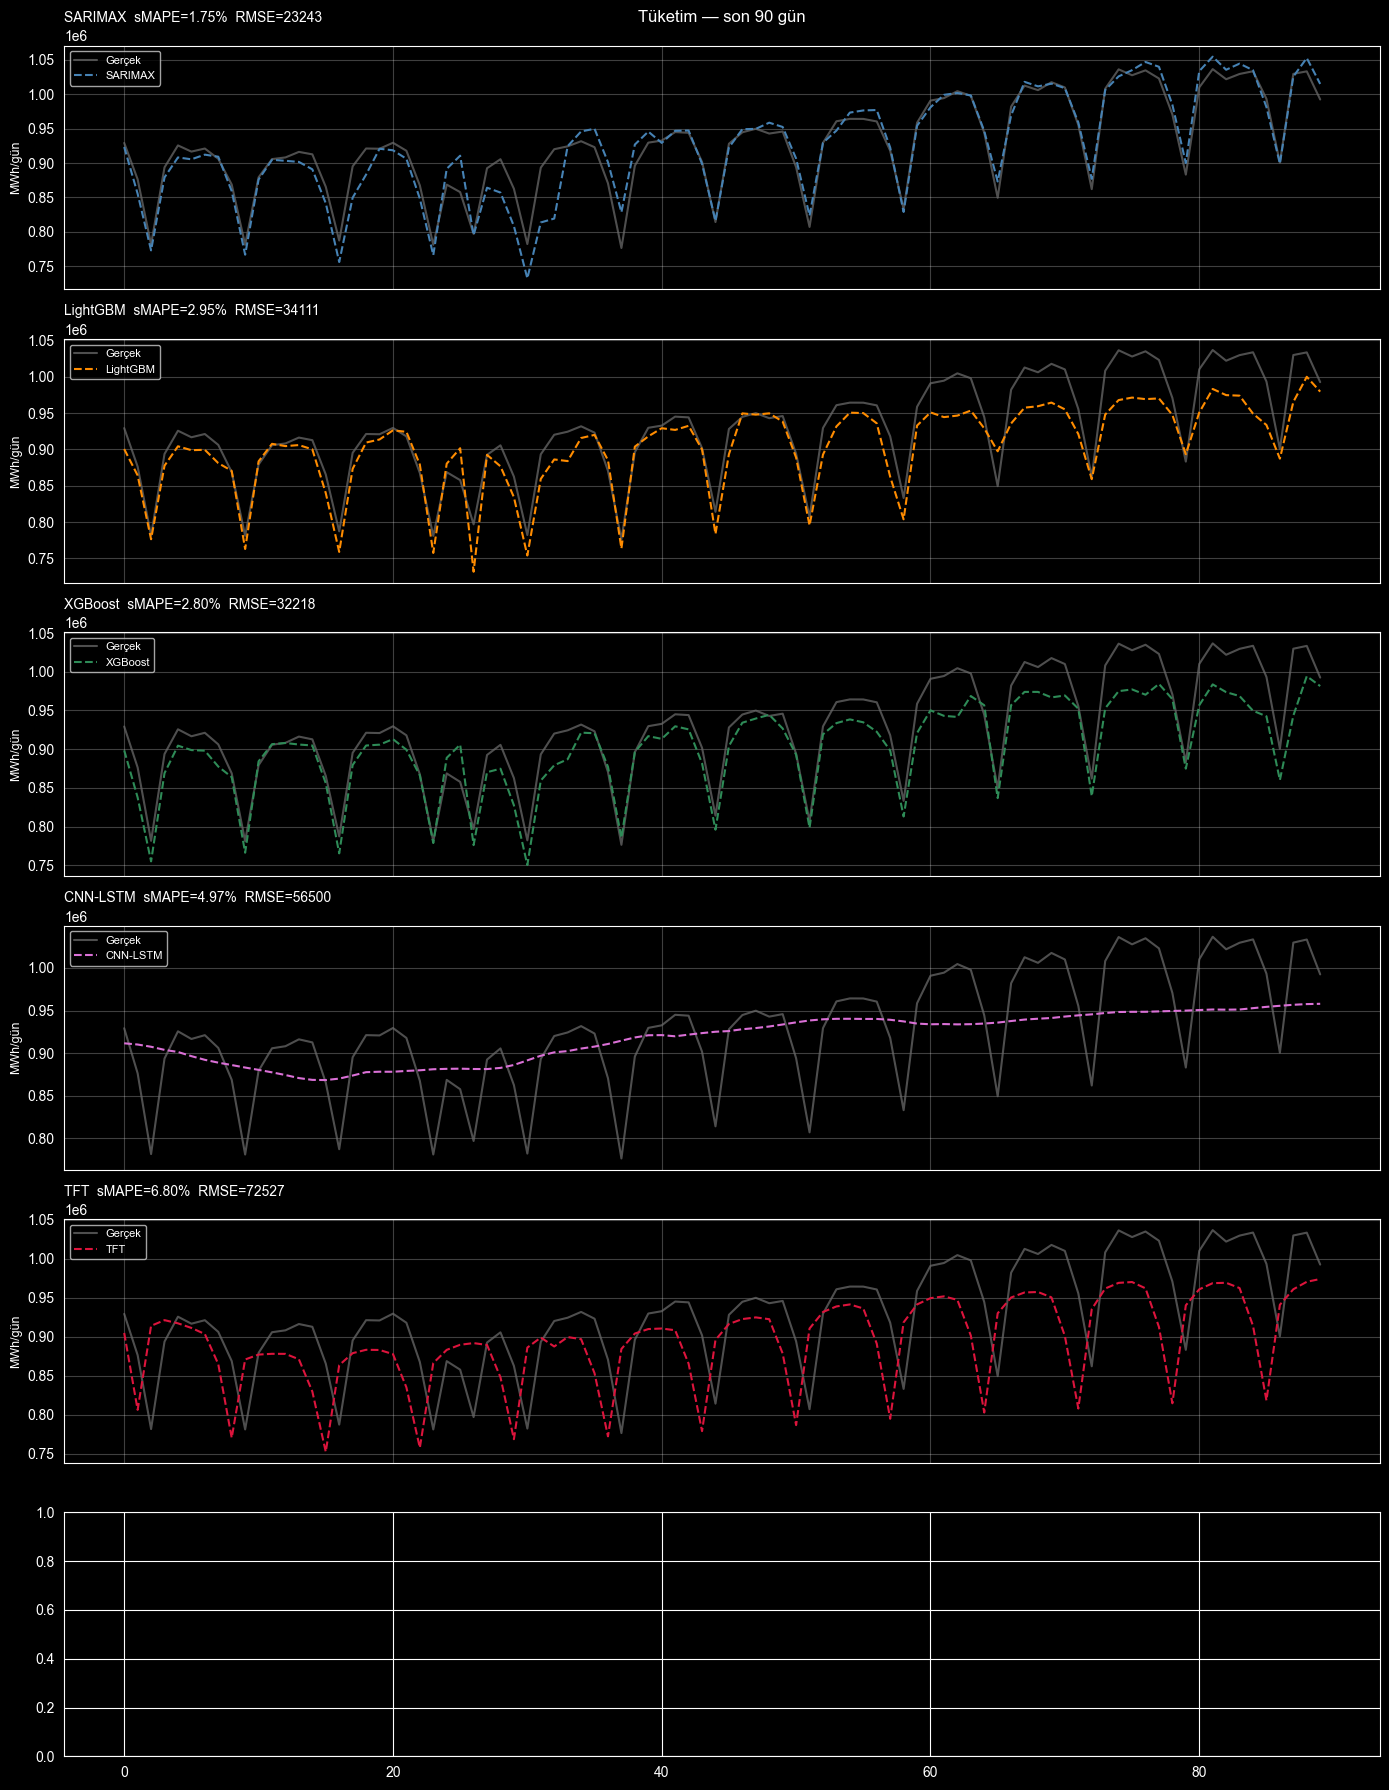

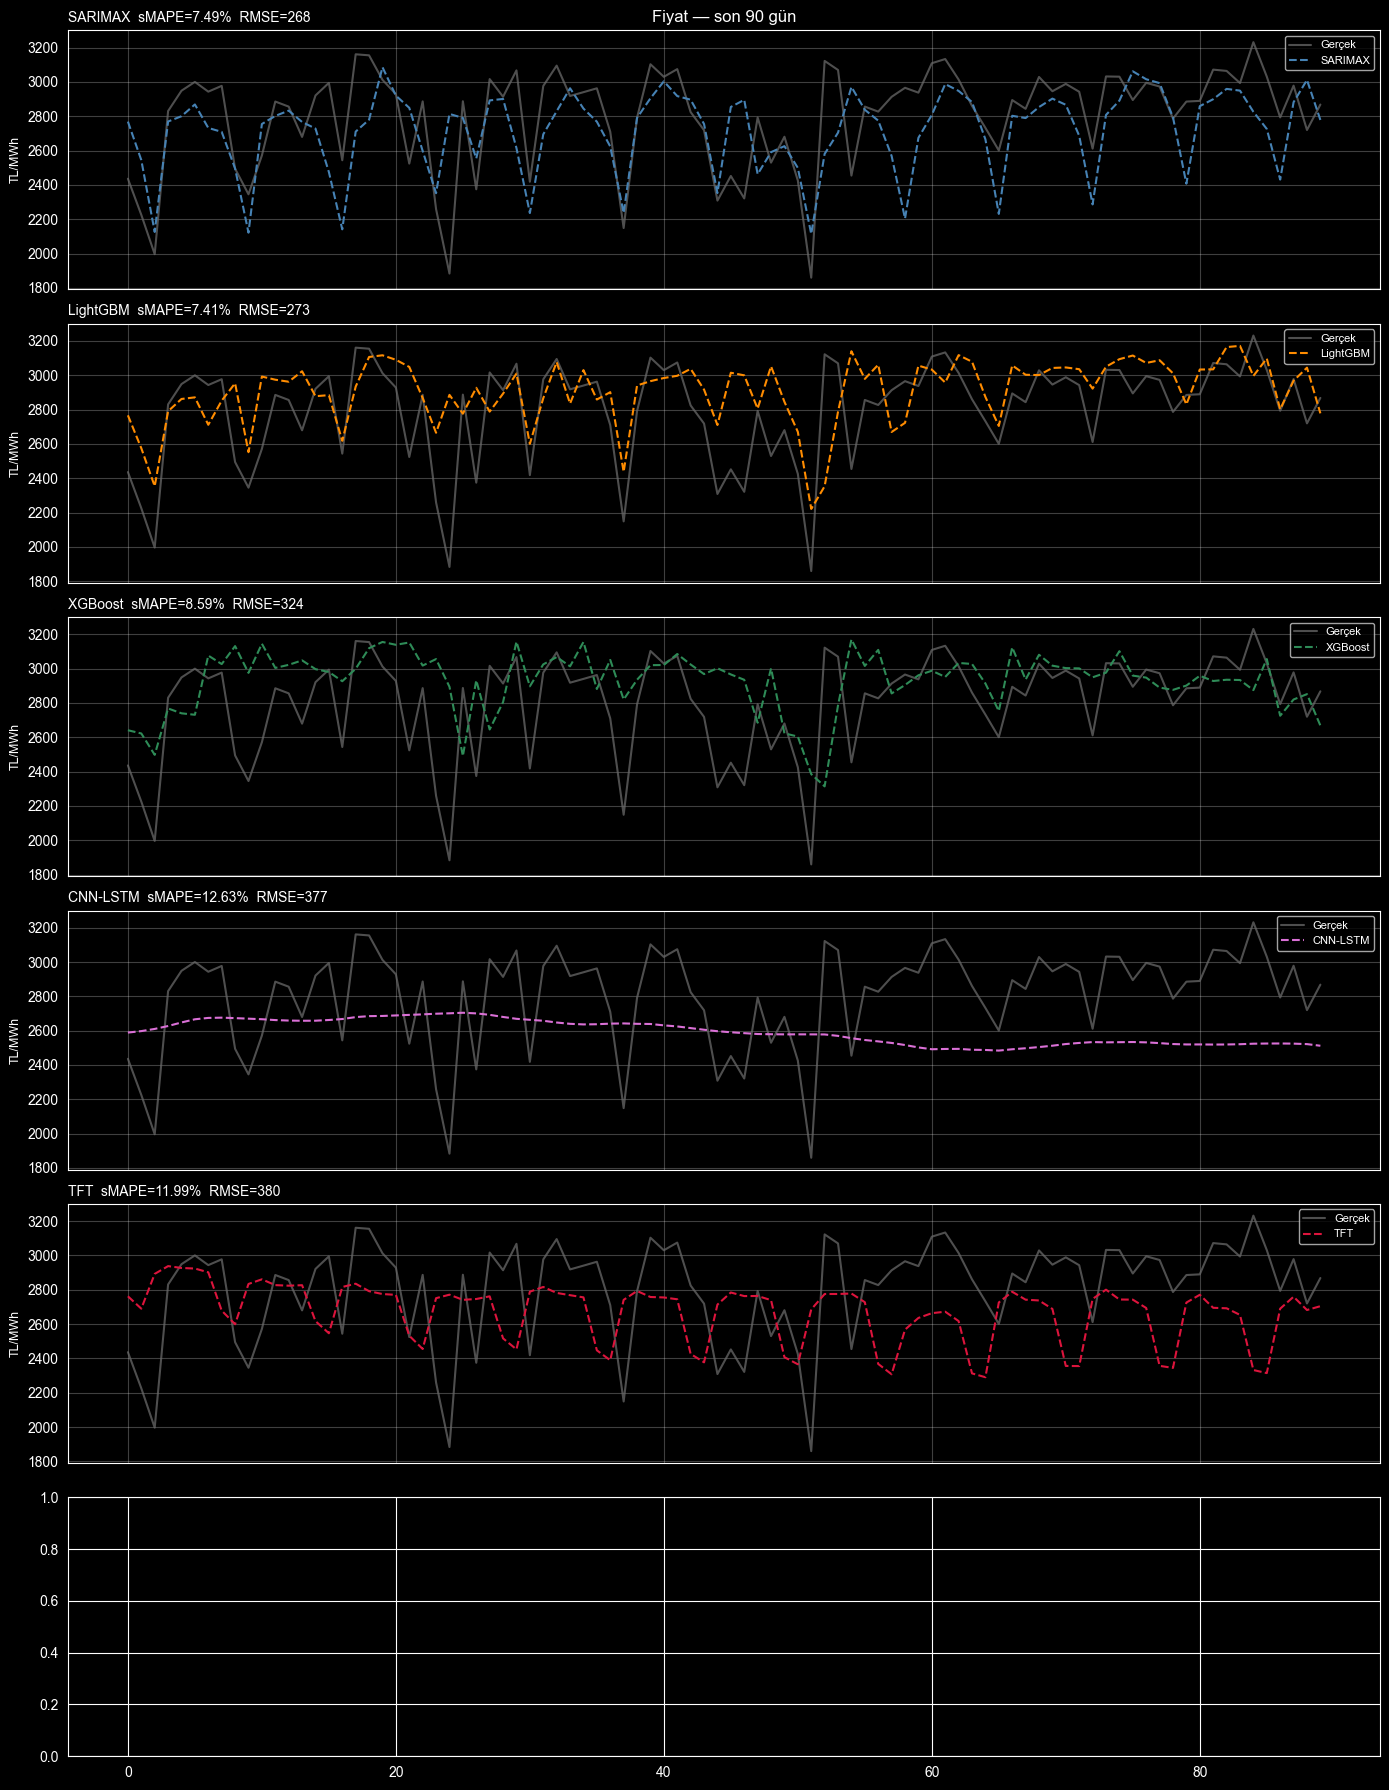

In [14]:
def plot_all_models(y_test, test_preds, hybrid, title, unit, n=90):
    """Her model + hibrit için ayrı satır."""
    models = list(test_preds.keys()) + ["HİBRİT"]
    preds  = list(test_preds.values()) + [hybrid]
    colors = ["steelblue", "darkorange", "seagreen", "orchid", "crimson"]
    fig, axes = plt.subplots(len(models), 1, figsize=(14, 3*len(models)), sharex=True)
    for ax, nm, pr, col in zip(axes, models, preds, colors):
        k = min(n, len(pr), len(y_test))
        yt_, yp_ = y_test[-k:], pr[-k:]
        ax.plot(yt_, color="dimgray", lw=1.5, label="Gerçek", alpha=.75)
        ax.plot(yp_, color=col,       lw=1.5, label=nm, ls="--")
        m = evaluate(yt_, yp_)
        ax.set_title(f"{nm}  sMAPE={m['sMAPE']:.2f}%  RMSE={m['RMSE']:.0f}",
                     loc="left", fontsize=10)
        ax.set_ylabel(unit, fontsize=9); ax.legend(fontsize=8); ax.grid(alpha=.25)
    axes[0].set_title(f"{title} — son {n} gün", fontsize=12)
    fig.tight_layout()
plot_all_models(y_test_t, TEST_PREDS_T, hybrid_test_t, "Tüketim", "MWh/gün")
plot_all_models(y_test_f, TEST_PREDS_F, hybrid_test_f, "Fiyat",   "TL/MWh")

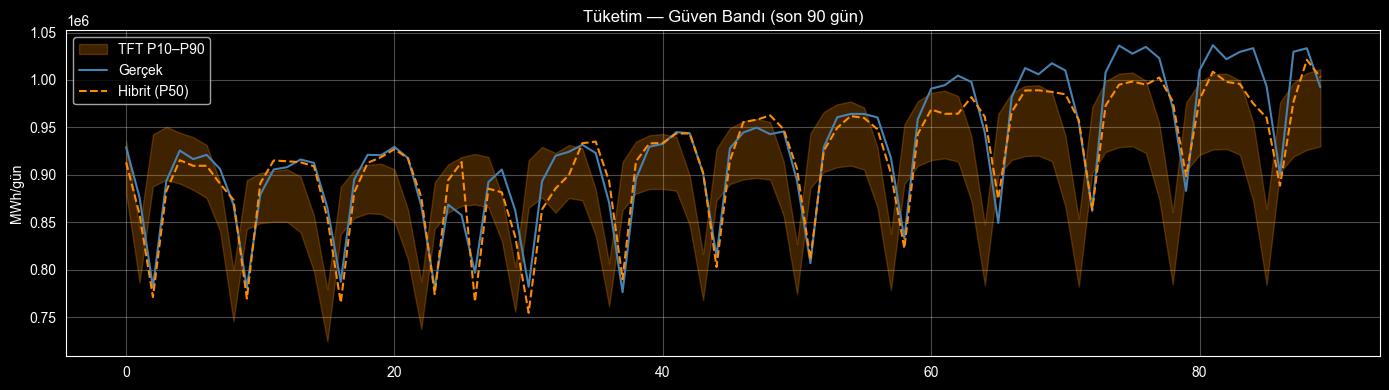

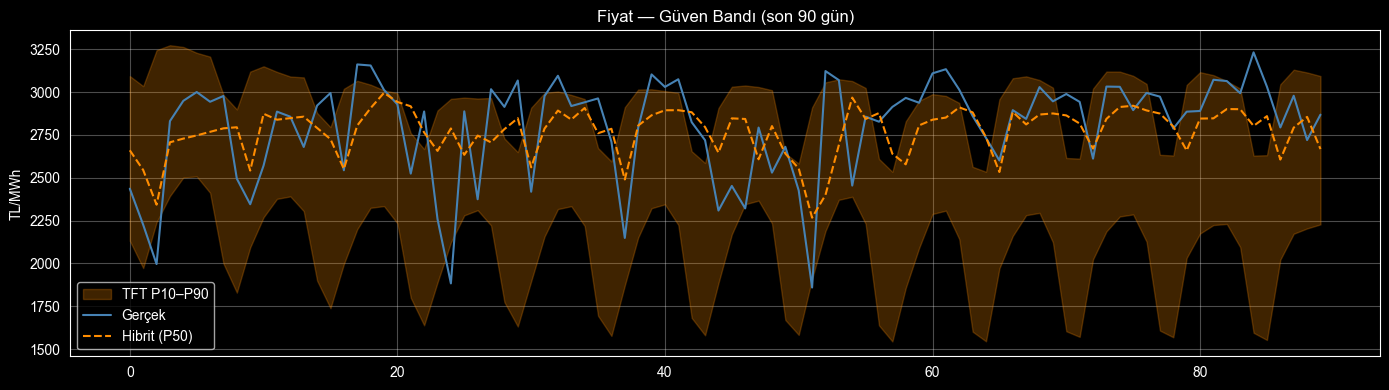

In [15]:
def plot_tft_intervals(y_test, hybrid, lo, hi, title, unit, n=90):
    """Hibrit medyan + TFT P10-P90 güven bandı."""
    k  = min(n, len(hybrid), len(y_test), lo.shape[0])
    yt = y_test[-k:]
    yp = hybrid[-k:]
    l_ = lo[-k:, 0]
    h_ = hi[-k:, 0]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(range(k), l_, h_, alpha=.25, color="darkorange", label="TFT P10–P90")
    ax.plot(yt, color="steelblue",  lw=1.5, label="Gerçek")
    ax.plot(yp, color="darkorange", lw=1.5, ls="--", label="Hibrit (P50)")
    ax.set_title(f"{title} — Güven Bandı (son {n} gün)")
    ax.set_ylabel(unit); ax.legend(); ax.grid(alpha=.3)
    fig.tight_layout()
plot_tft_intervals(y_test_t, hybrid_test_t, tft_lo_test_t, tft_hi_test_t, "Tüketim", "MWh/gün")
plot_tft_intervals(y_test_f, hybrid_test_f, tft_lo_test_f, tft_hi_test_f, "Fiyat",   "TL/MWh")

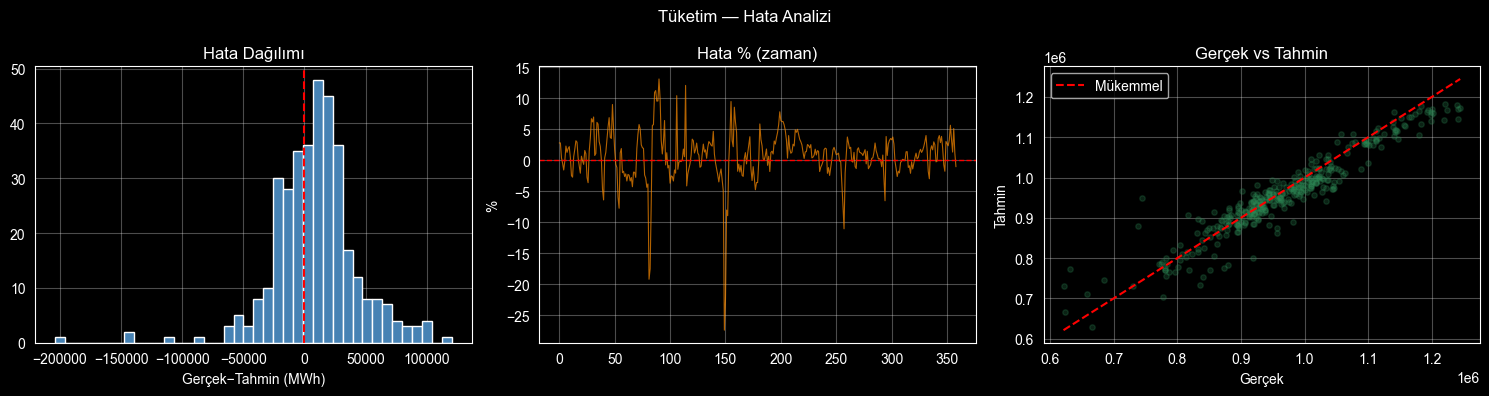

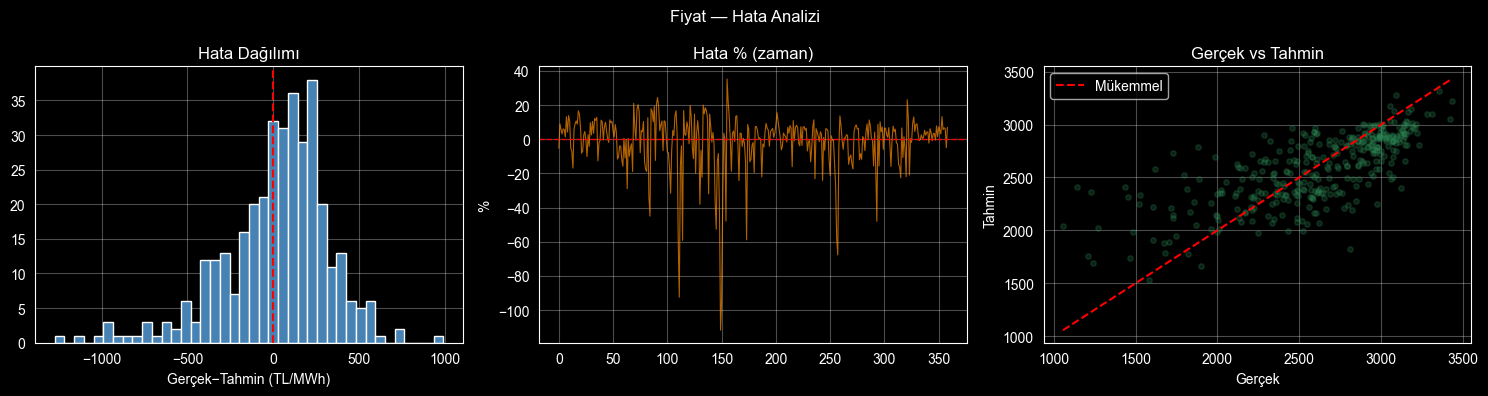

In [16]:
def plot_error_analysis(y_test, hybrid, title, unit):
    """Hata dağılımı + scatter."""
    n  = min(len(y_test), len(hybrid))
    yt = y_test[-n:]; yp = hybrid[-n:]
    err = yt - yp
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(err, bins=40, color="steelblue", edgecolor="white")
    axes[0].axvline(0, color="red", lw=1.5, ls="--")
    axes[0].set_title("Hata Dağılımı"); axes[0].set_xlabel(f"Gerçek−Tahmin ({unit})")
    axes[0].grid(alpha=.3)

    axes[1].plot(err / (np.abs(yt)+1e-8) * 100, color="darkorange", lw=.8, alpha=.7)
    axes[1].axhline(0, color="red", lw=1, ls="--")
    axes[1].set_title("Hata % (zaman)"); axes[1].set_ylabel("%"); axes[1].grid(alpha=.3)

    axes[2].scatter(yt, yp, alpha=.25, color="seagreen", s=15)
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    axes[2].plot([lo,hi],[lo,hi],"r--",lw=1.5,label="Mükemmel")
    axes[2].set_xlabel("Gerçek"); axes[2].set_ylabel("Tahmin")
    axes[2].set_title("Gerçek vs Tahmin"); axes[2].legend(); axes[2].grid(alpha=.3)

    fig.suptitle(f"{title} — Hata Analizi", fontsize=12)
    fig.tight_layout()
plot_error_analysis(y_test_t, hybrid_test_t, "Tüketim", "MWh")
plot_error_analysis(y_test_f, hybrid_test_f, "Fiyat",   "TL/MWh")

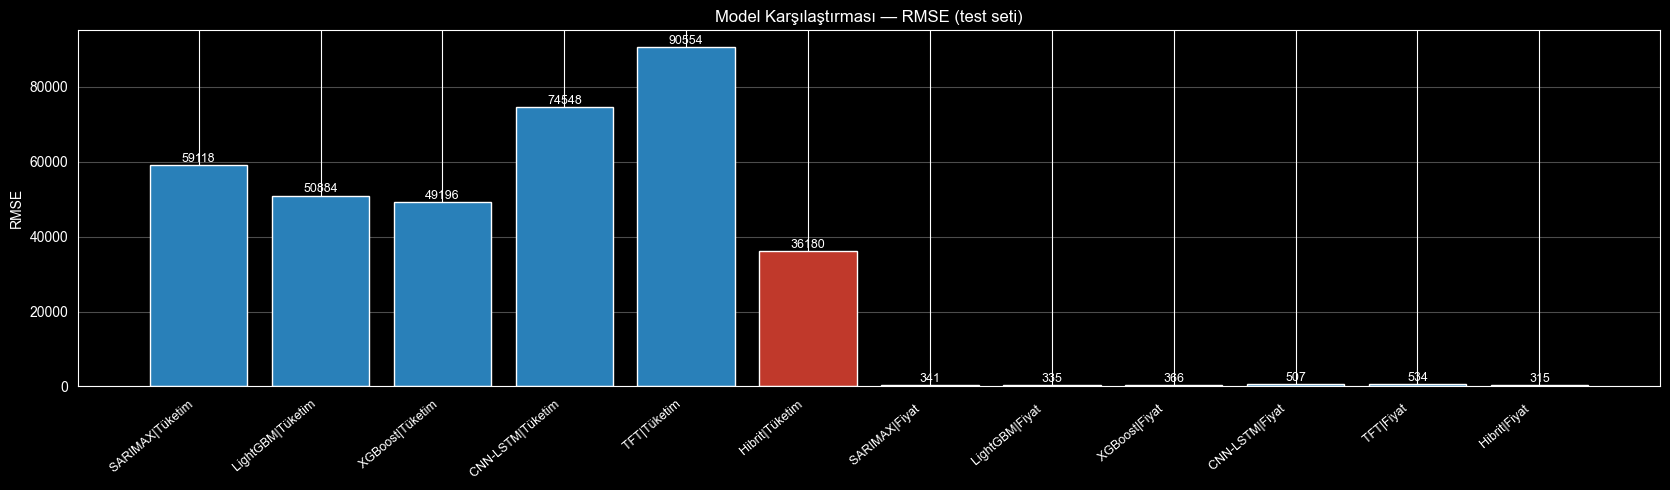

In [17]:
def plot_rmse_comparison(results: dict):
    """Tüm model-hedef çiftleri için RMSE bar."""
    labels = list(results.keys())
    rmses  = [results[k]["RMSE"] for k in labels]
    colors = ["#c0392b" if "Hibrit" in l else "#2980b9" for l in labels]
    fig, ax = plt.subplots(figsize=(max(10, len(labels)*1.4), 5))
    bars = ax.bar(labels, rmses, color=colors, edgecolor="white")
    for b, v in zip(bars, rmses):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(rmses)*.01,
                f"{v:.0f}", ha="center", fontsize=9)
    ax.set_title("Model Karşılaştırması — RMSE (test seti)")
    ax.set_ylabel("RMSE"); ax.grid(alpha=.3, axis="y")
    plt.xticks(rotation=40, ha="right", fontsize=9)
    fig.tight_layout()
plot_rmse_comparison(results)

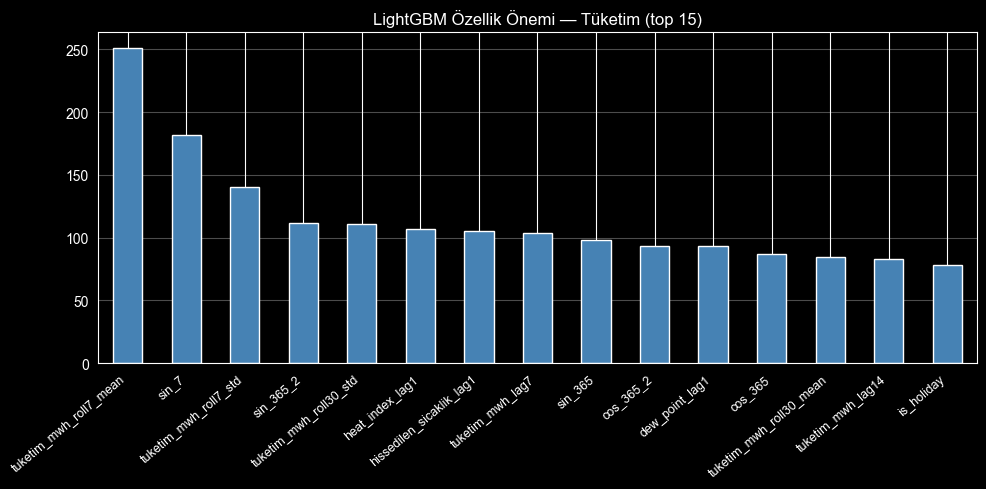

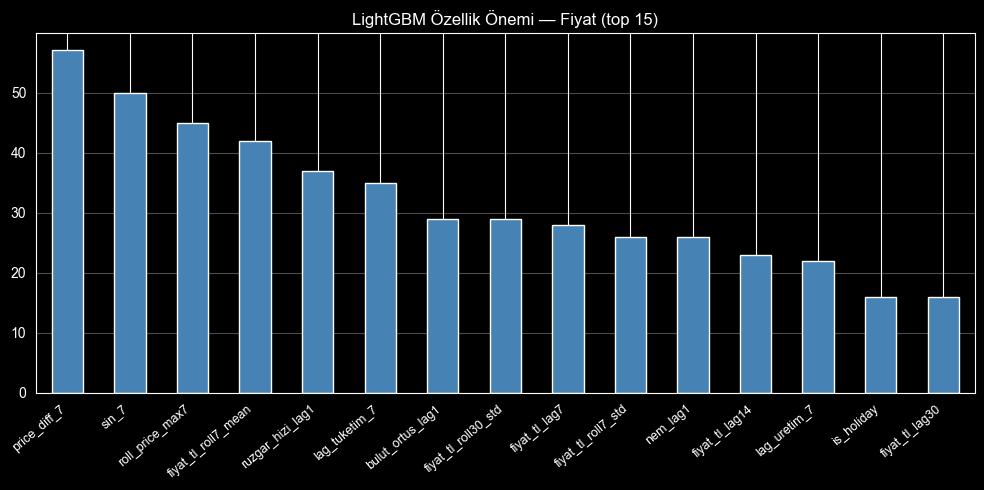

In [18]:
def plot_lgb_importance(model, feat_cols, label, top=15):
    imp = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    imp.head(top).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"LightGBM Özellik Önemi — {label} (top {top})")
    plt.xticks(rotation=40, ha="right", fontsize=9); ax.grid(alpha=.3, axis="y")
    fig.tight_layout()
plot_lgb_importance(lgb_t, feat_t, "Tüketim")
plot_lgb_importance(lgb_f, feat_f, "Fiyat")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn

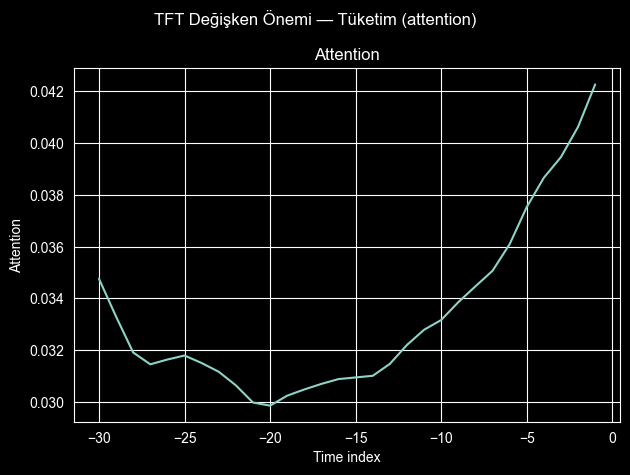

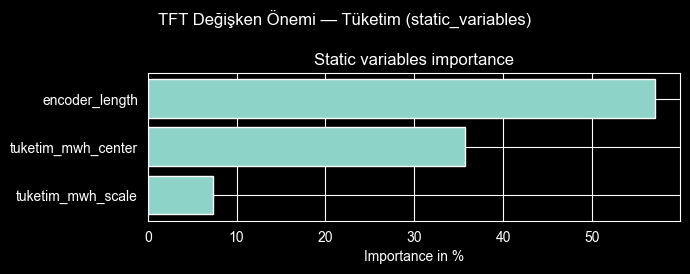

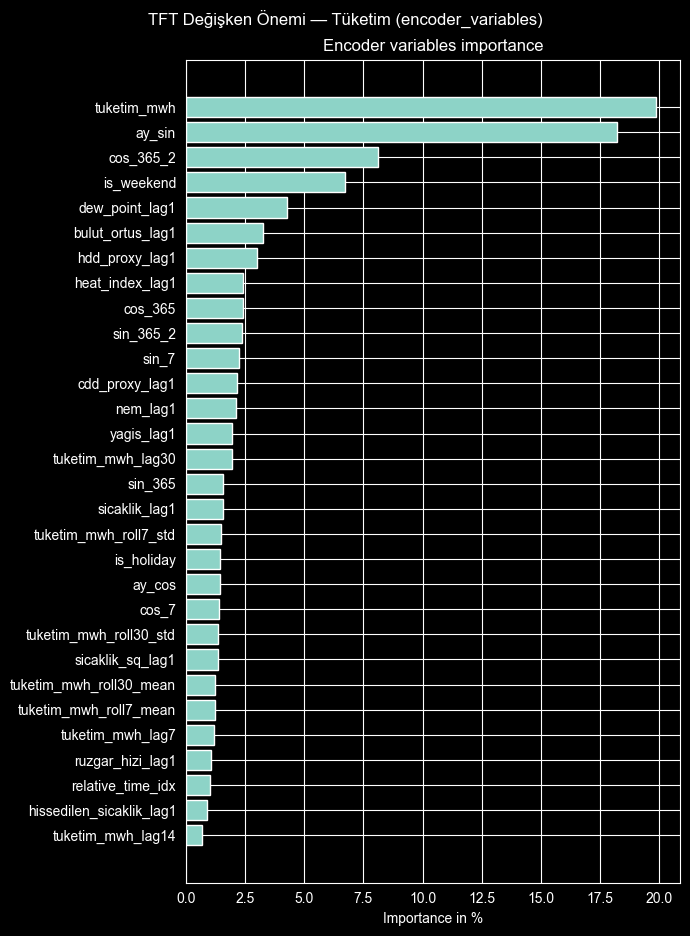

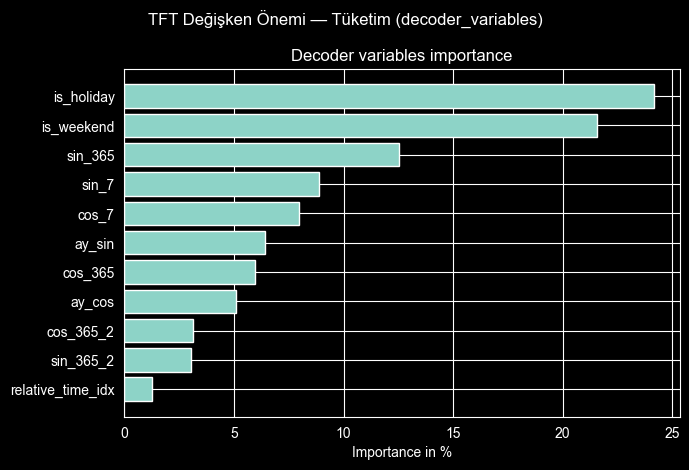

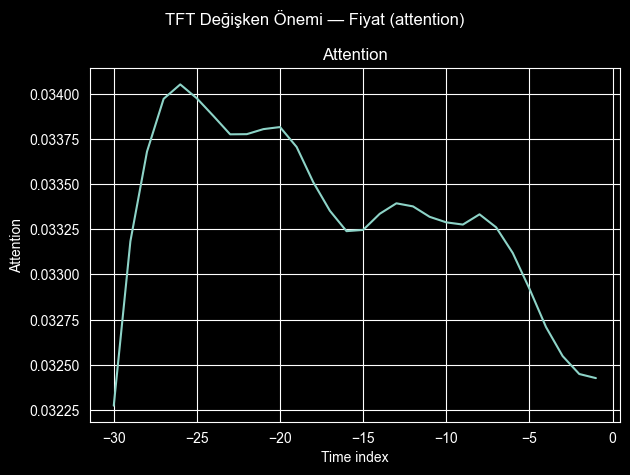

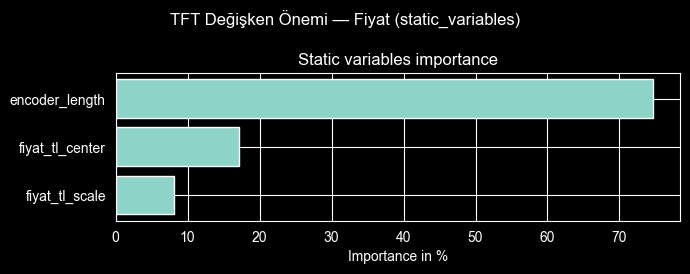

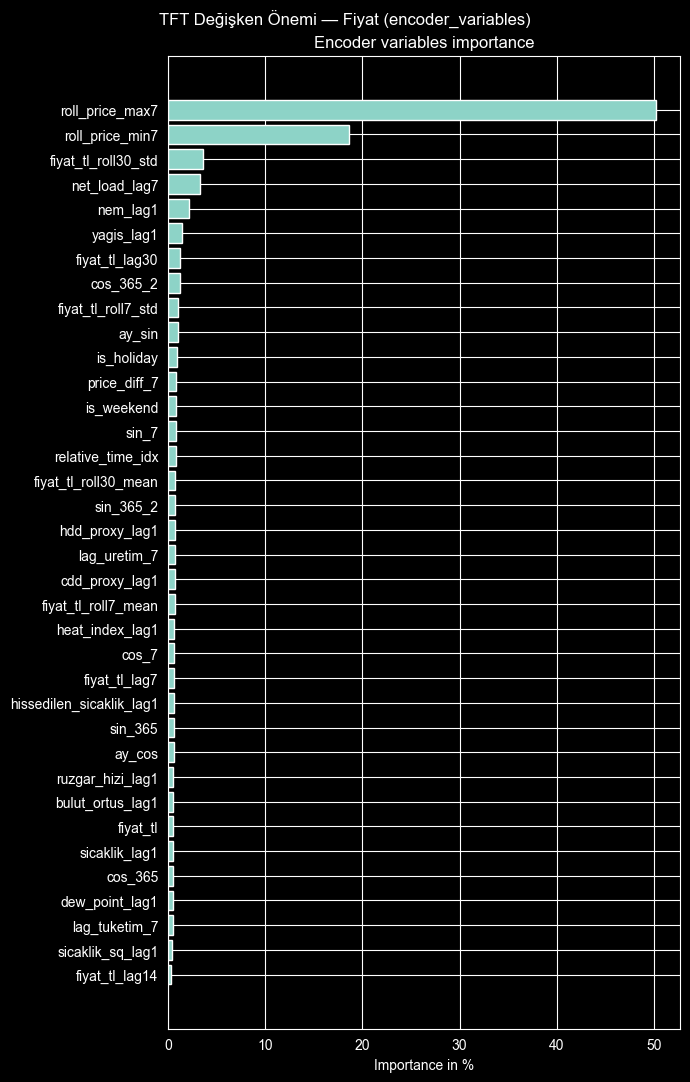

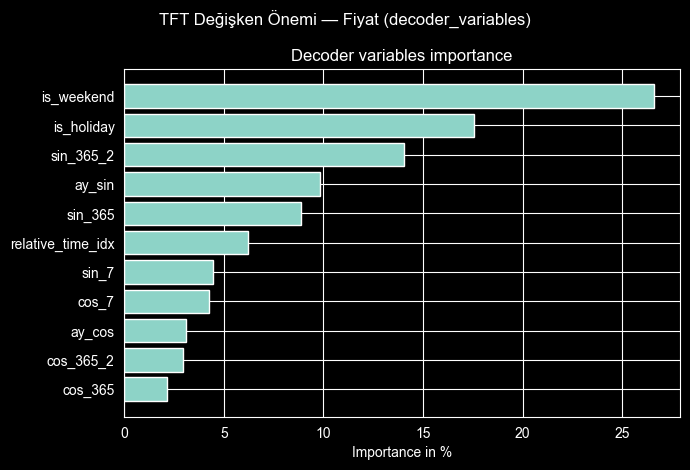

In [19]:
def plot_tft_variable_importance(model, train_ds, df_full, label, n_sample=200):
    """TFT dikkat ağırlıkları — deep_colab.ipynb'den."""
    df_s  = df_full.tail(n_sample).copy()

    # EKSİK OLAN KISIM BURASI: Kategorik değişkenleri string yap
    for col in KNOWN_FUTURE_CATS:
        if col in df_s.columns:
            df_s[col] = df_s[col].astype(int).astype(str)

    ds_s  = TimeSeriesDataSet.from_dataset(train_ds, df_s,
                                           stop_randomization=True,
                                           allow_missing_timesteps=True)
    dl_s  = ds_s.to_dataloader(train=False, batch_size=16,
                                num_workers=0, persistent_workers=False)
    with torch.no_grad():
        raw = model.predict(dl_s, mode="raw", return_x=True)
    interp = model.interpret_output(raw.output, reduction="mean")
    figs   = model.plot_interpretation(interp)
    for nm, fig in figs.items():
        fig.suptitle(f"TFT Değişken Önemi — {label} ({nm})", fontsize=12)
        fig.tight_layout()
    gc.collect()

# Şimdi tekrar çağırabilirsin
plot_tft_variable_importance(tft_t, tft_tr_t, df_t, "Tüketim")
plot_tft_variable_importance(tft_f, tft_tr_f, df_f, "Fiyat")

GELECEK 7 GÜN TAHMİNİ

feat_t sütun sayısı: 28  |  feat_f: 34

Gelecek 7 Gün Otoregresif Tahmini:
────────────────────────────────────────────────────────────
  Gün 1 (2026-01-01): Tüketim=     924,612 MWh/gün  Fiyat= 2604.37 TL/MWh
  Gün 2 (2026-01-02): Tüketim=     991,516 MWh/gün  Fiyat= 2653.71 TL/MWh
  Gün 3 (2026-01-03): Tüketim=     990,751 MWh/gün  Fiyat= 2673.48 TL/MWh
  Gün 4 (2026-01-04): Tüketim=     991,782 MWh/gün  Fiyat= 2653.86 TL/MWh
  Gün 5 (2026-01-05): Tüketim=     979,241 MWh/gün  Fiyat= 2668.09 TL/MWh
  Gün 6 (2026-01-06): Tüketim=     926,874 MWh/gün  Fiyat= 2607.21 TL/MWh
  Gün 7 (2026-01-07): Tüketim=     981,178 MWh/gün  Fiyat= 2647.63 TL/MWh

            tuketim_hybrid  fiyat_hybrid
2026-01-01        924611.8        2604.4
2026-01-02        991515.8        2653.7
2026-01-03        990751.1        2673.5
2026-01-04        991781.8        2653.9
2026-01-05        979241.0        2668.1
2026-01-06        926874.2        2607.2
2026-01-07        981178.2        2647.6


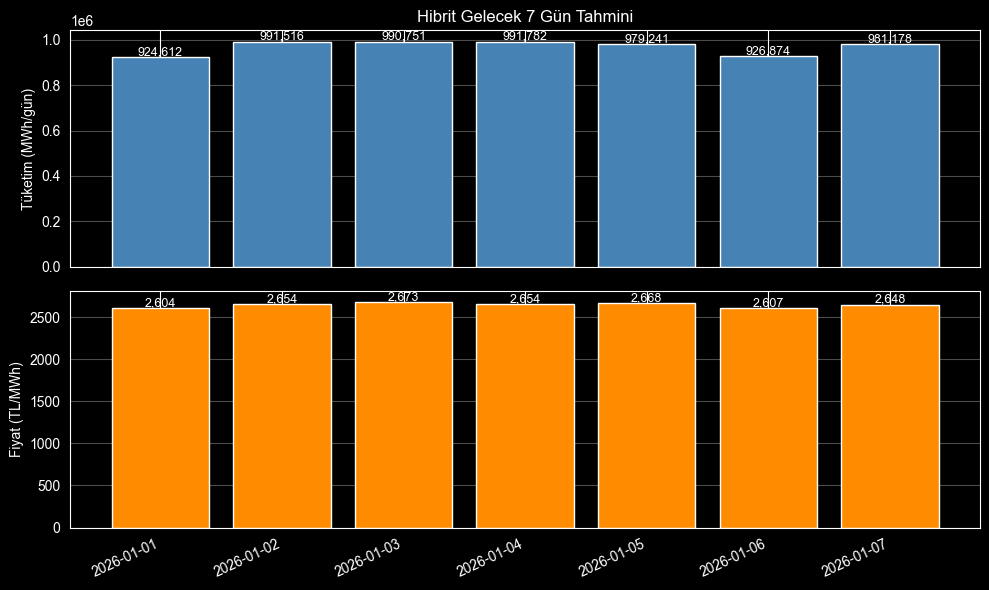


✓ Pipeline tamamlandı.


In [20]:
def forecast_next_7d_autoregressive_fixed(
    df_t, df_f, feat_t, feat_f,
    lgb_t, lgb_f, xgb_t, xgb_f,
    meta_t, meta_f,
    sarimax_model_t, sarimax_model_f,
    exog_sarimax_t, exog_sarimax_f,
):
    """
    7 günlük gerçek otoregresif tahmin — LightGBMError düzeltmesi.

    Hata nedeni:
        Önceki versiyonda row_t["tuketim_mwh_lag1"] ve row_f["fiyat_tl_lag1"]
        add_features() içinde hiç oluşturulmayan sütunlardı (yalnızca lag_7/14/30
        ve hava lag1'leri var). Bu satırlar feat_t/feat_f listesinde olmayan
        yeni bir sütun eklediği için model 28 yerine 29 özellik görüyordu.

    Düzeltme:
        - tuketim_mwh_lag1 / fiyat_tl_lag1 satırları kaldırıldı.
        - Güncellenebilen özellikler: lag_7, lag_14, lag_30, roll7/30 mean/std,
          hava_lag1, takvim, Fourier, hava türevleri.
        - Sadece feat_t / feat_f içinde VAR olan sütunlar güncellenir.
    """
    HORIZON = 7

    pred_tuk = []
    pred_fiy = []

    # Simülasyon DataFrame'leri — gerçek veriyle başlar
    sim_t = df_t.copy()
    sim_f = df_f.copy()

    # SARIMAX exog sütunları
    ecols_t = [c for c in SARIMAX_EXOG if c in df_t.columns]
    ecols_f = [c for c in SARIMAX_EXOG if c in df_f.columns]

    # CNN-LSTM / TFT proxy: son 7 test tahmininin ortalaması (0.0 yerine)
    cnn_proxy_t = float(np.mean(cnn_test_t[-7:])) if len(cnn_test_t) > 0 else float(df_t["tuketim_mwh"].iloc[-1])
    tft_proxy_t = float(np.mean(tft_test_t[-7:])) if len(tft_test_t) > 0 else float(df_t["tuketim_mwh"].iloc[-1])
    cnn_proxy_f = float(np.mean(cnn_test_f[-7:])) if len(cnn_test_f) > 0 else float(df_f["fiyat_tl"].iloc[-1])
    tft_proxy_f = float(np.mean(tft_test_f[-7:])) if len(tft_test_f) > 0 else float(df_f["fiyat_tl"].iloc[-1])

    # feat_t / feat_f'deki sütunları bir kez kontrol et (debugging için)
    print(f"feat_t sütun sayısı: {len(feat_t)}  |  feat_f: {len(feat_f)}")

    print("\nGelecek 7 Gün Otoregresif Tahmini:")
    print("─" * 60)

    for day in range(HORIZON):
        # ── Tarih ve takvim ───────────────────────────────────────
        next_date_t = sim_t.index[-1] + pd.Timedelta(days=1)
        next_date_f = sim_f.index[-1] + pd.Timedelta(days=1)
        is_weekend_next = int(next_date_t.dayofweek >= 5)
        try:
            import holidays as hd
            is_holiday_next = int(next_date_t in hd.Turkey(years=next_date_t.year))
        except ImportError:
            is_holiday_next = 0

        # ── Hava (persistence) ────────────────────────────────────
        last_weather_t = sim_t[["sicaklik", "hissedilen_sicaklik", "nem",
                                 "ruzgar_hizi", "bulut_ortus", "yagis"]].iloc[-1]
        last_weather_f = sim_f[["sicaklik", "hissedilen_sicaklik", "nem",
                                 "ruzgar_hizi", "bulut_ortus", "yagis"]].iloc[-1]

        # ─────────────────────────────────────────────────────────
        # TÜKETİM satırı — yalnızca feat_t'de VAR olan sütunlar güncellenir
        # ─────────────────────────────────────────────────────────
        row_t = sim_t[feat_t].iloc[-1].copy()

        # Hedef lagları (lag_1 yok — add_features sadece lag_7/14/30 üretir)
        if "tuketim_mwh_lag7" in row_t.index:
            row_t["tuketim_mwh_lag7"] = (
                sim_t["tuketim_mwh"].iloc[-(7 - day)] if day < 7
                else pred_tuk[day - 7]
            )
        if "tuketim_mwh_lag14" in row_t.index:
            row_t["tuketim_mwh_lag14"] = (
                sim_t["tuketim_mwh"].iloc[-(14 - day)] if day < 14
                else pred_tuk[day - 14]
            )
        if "tuketim_mwh_lag30" in row_t.index:
            # 7 günlük ufukta lag_30 hiç değişmez (hep gerçek geçmişten gelir)
            row_t["tuketim_mwh_lag30"] = sim_t["tuketim_mwh"].iloc[-30]

        # Rolling özellikler — mevcut pred_tuk + sim_t geçmişinden hesapla
        history_t = list(sim_t["tuketim_mwh"].values) + pred_tuk
        if "tuketim_mwh_roll7_mean" in row_t.index:
            row_t["tuketim_mwh_roll7_mean"]  = float(np.mean(history_t[-7:]))
        if "tuketim_mwh_roll7_std" in row_t.index:
            row_t["tuketim_mwh_roll7_std"]   = float(np.std(history_t[-7:]))
        if "tuketim_mwh_roll30_mean" in row_t.index:
            row_t["tuketim_mwh_roll30_mean"] = float(np.mean(history_t[-30:]))
        if "tuketim_mwh_roll30_std" in row_t.index:
            row_t["tuketim_mwh_roll30_std"]  = float(np.std(history_t[-30:]))

        # Hava lag1 (persistence: bugünkü hava = dünün tahmini)
        for hcol in ["sicaklik", "hissedilen_sicaklik", "nem",
                     "ruzgar_hizi", "bulut_ortus", "yagis",
                     "sicaklik_sq", "hdd_proxy", "cdd_proxy",
                     "heat_index", "dew_point"]:
            lc = f"{hcol}_lag1"
            if lc in row_t.index:
                row_t[lc] = last_weather_t.get(hcol, row_t[lc])

        # Takvim
        if "is_weekend" in row_t.index: row_t["is_weekend"] = is_weekend_next
        if "is_holiday" in row_t.index: row_t["is_holiday"] = is_holiday_next

        # Fourier
        t_idx = len(sim_t)
        for col, val in [
            ("sin_7",     np.sin(2*np.pi*t_idx/7)),
            ("cos_7",     np.cos(2*np.pi*t_idx/7)),
            ("sin_365",   np.sin(2*np.pi*t_idx/365.25)),
            ("cos_365",   np.cos(2*np.pi*t_idx/365.25)),
            ("sin_365_2", np.sin(4*np.pi*t_idx/365.25)),
            ("cos_365_2", np.cos(4*np.pi*t_idx/365.25)),
            ("ay_sin",    np.sin(2*np.pi*next_date_t.month/12)),
            ("ay_cos",    np.cos(2*np.pi*next_date_t.month/12)),
        ]:
            if col in row_t.index:
                row_t[col] = val

        # Hava türevleri
        T = float(last_weather_t["sicaklik"])
        H = float(last_weather_t["nem"])
        for col, val in [
            ("sicaklik_sq", T**2),
            ("hdd_proxy",   max(0.0, 18-T)),
            ("cdd_proxy",   max(0.0, T-22)),
            ("heat_index",  T*H/100),
            ("dew_point",   T-H/5),
        ]:
            lc = f"{col}_lag1"        # add_features bunları _lag1 olarak ekler
            if lc in row_t.index:
                row_t[lc] = val

        # Güvenlik: satırın boyutunu kontrol et
        assert len(row_t) == len(feat_t), (
            f"Tüketim satır boyutu uyumsuz: {len(row_t)} != {len(feat_t)}\n"
            f"Fazla sütunlar: {set(row_t.index) - set(feat_t)}\n"
            f"Eksik sütunlar: {set(feat_t) - set(row_t.index)}"
        )
        row_input_t = pd.DataFrame([row_t.values], columns=feat_t)

        # ─────────────────────────────────────────────────────────
        # FİYAT satırı — aynı mantık
        # ─────────────────────────────────────────────────────────
        row_f = sim_f[feat_f].iloc[-1].copy()

        # Hedef lagları (lag_1 yok)
        if "fiyat_tl_lag7" in row_f.index:
            row_f["fiyat_tl_lag7"] = (
                sim_f["fiyat_tl"].iloc[-(7 - day)] if day < 7
                else pred_fiy[day - 7]
            )
        if "fiyat_tl_lag14" in row_f.index:
            row_f["fiyat_tl_lag14"] = (
                sim_f["fiyat_tl"].iloc[-(14 - day)] if day < 14
                else pred_fiy[day - 14]
            )
        if "fiyat_tl_lag30" in row_f.index:
            row_f["fiyat_tl_lag30"] = sim_f["fiyat_tl"].iloc[-30]

        # Rolling
        history_f = list(sim_f["fiyat_tl"].values) + pred_fiy
        if "fiyat_tl_roll7_mean"  in row_f.index:
            row_f["fiyat_tl_roll7_mean"]  = float(np.mean(history_f[-7:]))
        if "fiyat_tl_roll7_std"   in row_f.index:
            row_f["fiyat_tl_roll7_std"]   = float(np.std(history_f[-7:]))
        if "fiyat_tl_roll30_mean" in row_f.index:
            row_f["fiyat_tl_roll30_mean"] = float(np.mean(history_f[-30:]))
        if "fiyat_tl_roll30_std"  in row_f.index:
            row_f["fiyat_tl_roll30_std"]  = float(np.std(history_f[-30:]))

        # Fiyata özgü laglar
        if "price_diff_7" in row_f.index:
            row_f["price_diff_7"] = history_f[-1] - history_f[-8] if len(history_f) >= 8 else 0.0
        if "roll_price_max7" in row_f.index:
            row_f["roll_price_max7"] = float(np.max(history_f[-7:]))
        if "roll_price_min7" in row_f.index:
            row_f["roll_price_min7"] = float(np.min(history_f[-7:]))
        if "lag_tuketim_7" in row_f.index:
            row_f["lag_tuketim_7"] = (
                sim_t["tuketim_mwh"].iloc[-(7 - day)] if day < 7
                else pred_tuk[day - 7]
            )
        if "net_load_lag7" in row_f.index:
            # net_load = tuketim - uretim; uretim persistence
            last_uretim = float(sim_t["uretim_mwh"].iloc[-1])
            lag_tuk_7 = float(row_f.get("lag_tuketim_7", sim_t["tuketim_mwh"].iloc[-7]))
            row_f["net_load_lag7"] = lag_tuk_7 - last_uretim

        # Hava lag1
        for hcol in ["sicaklik", "hissedilen_sicaklik", "nem",
                     "ruzgar_hizi", "bulut_ortus", "yagis",
                     "sicaklik_sq", "hdd_proxy", "cdd_proxy",
                     "heat_index", "dew_point"]:
            lc = f"{hcol}_lag1"
            if lc in row_f.index:
                row_f[lc] = last_weather_f.get(hcol, row_f[lc])

        # Takvim
        if "is_weekend" in row_f.index: row_f["is_weekend"] = is_weekend_next
        if "is_holiday" in row_f.index: row_f["is_holiday"] = is_holiday_next

        # Fourier
        t_idx_f = len(sim_f)
        for col, val in [
            ("sin_7",     np.sin(2*np.pi*t_idx_f/7)),
            ("cos_7",     np.cos(2*np.pi*t_idx_f/7)),
            ("sin_365",   np.sin(2*np.pi*t_idx_f/365.25)),
            ("cos_365",   np.cos(2*np.pi*t_idx_f/365.25)),
            ("sin_365_2", np.sin(4*np.pi*t_idx_f/365.25)),
            ("cos_365_2", np.cos(4*np.pi*t_idx_f/365.25)),
            ("ay_sin",    np.sin(2*np.pi*next_date_f.month/12)),
            ("ay_cos",    np.cos(2*np.pi*next_date_f.month/12)),
        ]:
            if col in row_f.index:
                row_f[col] = val

        # Hava türevleri
        T = float(last_weather_f["sicaklik"])
        H = float(last_weather_f["nem"])
        for col, val in [
            ("sicaklik_sq", T**2),
            ("hdd_proxy",   max(0.0, 18-T)),
            ("cdd_proxy",   max(0.0, T-22)),
            ("heat_index",  T*H/100),
            ("dew_point",   T-H/5),
        ]:
            lc = f"{col}_lag1"
            if lc in row_f.index:
                row_f[lc] = val

        # Güvenlik kontrolü
        assert len(row_f) == len(feat_f), (
            f"Fiyat satır boyutu uyumsuz: {len(row_f)} != {len(feat_f)}\n"
            f"Fazla sütunlar: {set(row_f.index) - set(feat_f)}\n"
            f"Eksik sütunlar: {set(feat_f) - set(row_f.index)}"
        )
        row_input_f = pd.DataFrame([row_f.values], columns=feat_f)

        # ── GBM tahminleri ────────────────────────────────────────
        lgb_nt = float(lgb_t.predict(row_input_t)[0])
        xgb_nt = float(xgb_t.predict(row_input_t)[0])
        lgb_nf = float(lgb_f.predict(row_input_f)[0])
        xgb_nf = float(xgb_f.predict(row_input_f)[0])

        # ── SARIMAX ───────────────────────────────────────────────
        last_exog_t = sim_t[ecols_t].iloc[[-1]].astype(float) if ecols_t else None
        last_exog_f = sim_f[ecols_f].iloc[[-1]].astype(float) if ecols_f else None
        sar_nt = float(sarimax_model_t.forecast(
          steps=1, exog=last_exog_t.values if last_exog_t is not None else None))
        sar_nf = float(sarimax_model_f.forecast(
          steps=1, exog=last_exog_f.values if last_exog_f is not None else None))

        # ── CNN-LSTM / TFT proxy ──────────────────────────────────
        cnn_nt = cnn_proxy_t
        tft_nt = tft_proxy_t
        cnn_nf = cnn_proxy_f
        tft_nf = tft_proxy_f

        # ── Meta kombinasyon ──────────────────────────────────────
        # meta_t / meta_f train_meta_normalized ile eğitildiyse scaler gerekir.
        # train_meta_v2 ile eğitildiyse doğrudan predict yapılır.
        # İki durumu da kapsayacak şekilde:
        all_preds_t = {
            "SARIMAX":  sar_nt,
            "LightGBM": lgb_nt,
            "XGBoost":  xgb_nt,
            "CNN-LSTM": cnn_nt,
            "TFT":      tft_nt,
        }
        all_preds_f = {
            "SARIMAX":  sar_nf,
            "LightGBM": lgb_nf,
            "XGBoost":  xgb_nf,
            "CNN-LSTM": cnn_nf,
            "TFT":      tft_nf,
        }

        stack_t = np.array([[all_preds_t[nm] for nm in active_t]])  # ← active_t kaç model ise o kadar sütun
        stack_f = np.array([[all_preds_f[nm] for nm in active_f]])

        stack_t_sc  = scaler_t.transform(stack_t)
        stack_f_sc  = scaler_f.transform(stack_f)
        hybrid_nt   = float(meta_t.predict(stack_t_sc)[0])
        hybrid_nf   = float(meta_f.predict(stack_f_sc)[0])

        pred_tuk.append(hybrid_nt)
        pred_fiy.append(hybrid_nf)

        print(f"  Gün {day+1} ({next_date_t.date()}): "
              f"Tüketim={hybrid_nt:>12,.0f} MWh/gün  "
              f"Fiyat={hybrid_nf:>8.2f} TL/MWh")

        # ── sim_t / sim_f'e yeni satır ekle ──────────────────────
        new_row_t = sim_t.iloc[[-1]].copy()
        new_row_t.index = [next_date_t]
        new_row_t["tuketim_mwh"] = hybrid_nt
        sim_t = pd.concat([sim_t, new_row_t])
        sim_t = sim_t.infer_objects()   # object sütunları tekrar sayısal yap

        new_row_f = sim_f.iloc[[-1]].copy()
        new_row_f.index = [next_date_f]
        new_row_f["fiyat_tl"] = hybrid_nf
        sim_f = pd.concat([sim_f, new_row_f])
        sim_f = sim_f.infer_objects()

    return pred_tuk, pred_fiy


# ── Çalıştır ─────────────────────────────────────────────────────────────────
ecols_t = [c for c in SARIMAX_EXOG if c in df_t.columns]
ecols_f = [c for c in SARIMAX_EXOG if c in df_f.columns]

pred_tuk, pred_fiy = forecast_next_7d_autoregressive_fixed(
    df_t=df_t, df_f=df_f,
    feat_t=feat_t, feat_f=feat_f,
    lgb_t=lgb_t, lgb_f=lgb_f,
    xgb_t=xgb_t, xgb_f=xgb_f,
    meta_t=meta_t, meta_f=meta_f,
    sarimax_model_t=sarimax_t, sarimax_model_f=sarimax_f,
    exog_sarimax_t=df_t[ecols_t] if ecols_t else None,
    exog_sarimax_f=df_f[ecols_f] if ecols_f else None,
)

# ── Sonuçları DataFrame'e dök ve görselleştir ────────────────────────────────
future_dates = pd.date_range(
    df_t.index[-1] + pd.Timedelta(days=1), periods=7, freq="D"
)
fc_df = pd.DataFrame(
    {"tuketim_hybrid": pred_tuk, "fiyat_hybrid": pred_fiy},
    index=future_dates,
)

print("\n" + "="*50)
print(fc_df[["tuketim_hybrid", "fiyat_hybrid"]].to_string(float_format="{:.1f}".format))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
x = range(7)

a1.bar(x, fc_df["tuketim_hybrid"], color="steelblue", edgecolor="white")
a1.set_ylabel("Tüketim (MWh/gün)")
a1.set_title("Hibrit Gelecek 7 Gün Tahmini")
a1.grid(alpha=.3, axis="y")
for i, v in enumerate(fc_df["tuketim_hybrid"]):
    a1.text(i, v + abs(v)*.01, f"{v:,.0f}", ha="center", fontsize=9)

a2.bar(x, fc_df["fiyat_hybrid"], color="darkorange", edgecolor="white")
a2.set_ylabel("Fiyat (TL/MWh)")
a2.set_xticks(x)
a2.set_xticklabels([str(d.date()) for d in fc_df.index], rotation=25, ha="right")
a2.grid(alpha=.3, axis="y")
for i, v in enumerate(fc_df["fiyat_hybrid"]):
    a2.text(i, v + abs(v)*.01, f"{v:,.0f}", ha="center", fontsize=9)

fig.tight_layout()
plt.show()

print("\n✓ Pipeline tamamlandı.")